# 201 — MHC stress-test across ALL alphabets and ksizes (human→mouse orthologs)

**Why MHC, and why every combo.** Notebook 200 ranked every alphabet × k-size combo it has real
genome-wide results for — protein, dayhoff, hp, and all 6 dash-named HP variants (hp-lehninger,
hp-lehninger-plus-c, hp-kyte-doolittle, hp-pbotc-1st-ed, hp-thomas-dill, hp-thomas-dill-no-c), each
across its full validated k range — against MGI ground truth and a matched-scope OrthoFinder
baseline (`ou.load_all_alphabet_ksize_combos()`, the single source of truth shared with 200/203/206).
That's ~99 combos across 9 alphabets. But genome-wide F1 is dominated by high-identity orthologs; it
says nothing about the **hardest** case. MHC is that hardest case: simultaneously kmerseek's weakest
structural class (the antigen-recognition domain is an open β-sheet + α-helix, class-b-heavy) and the
most polymorphic gene family in the genome. This notebook re-runs the same 25-gene human MHC query
against each combo's mouse index and asks three questions per combo:

- **(a)** ortholog recovery / AUC on the HLA↔H-2 set *alone*;
- **(b)** whether the shared k-mers land on the **peptide-binding ARD residues** or ride the conserved scaffold;
- **(c)** how the peptide-binding **ARD** compares to the Ig-like domains **within the same molecules**.

Decision rule: does the genome-wide ranking hold up under this harder test, or does a different combo
(or alphabet) actually pass (a) and (b) cleanly here?

**Every alphabet gets its full k range, not just a top-5.** An earlier version of this notebook
restricted itself to the top-5-per-alphabet from 200's original protein/dayhoff/hp sweep plus a
partial hand-picked extension of 3 HP variants (see git history for that version) — this version
drops the restriction entirely and pulls in every combo 200 has validated, HP-family included: HP
(hp_lehninger and its 5 siblings) is the alphabet family this project cares about most, see
[[feedback_hp_alphabet_priority]]; protein and dayhoff are here as baseline comparisons, at their own
full validated k ranges too, not just their old top-5.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import ortholog_analysis_utils as ou
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve, precision_recall_curve

RES      = Path("/Users/olga/data/gencode/results-human-mouse-orthologs")

# ALL alphabets and ksizes notebook 200 confirmed have real genome-wide results for -- protein,
# dayhoff, hp, and all 6 dash-named HP variants, each across its full validated k range. Single
# source of truth (ou.load_all_alphabet_ksize_combos, reads 200's two sweep CSVs) so this can't
# drift from what 200 actually scored -- add a new alphabet/ksize there first and it shows up here.
combos_df = ou.load_all_alphabet_ksize_combos()
# Drop the legacy "hp" encoding: kmerseek's --help states hp IS the Lehninger classification, and
# they are byte-identical here (hp_k26 and hp_lehninger_k26 both give exactly 3,266 MHC rows). It
# survives in 200's sweep only because those combos predate the explicitly-named HP variants, and
# its files are the older human_vs_mouse.hp.k*.results.csv.gz set -- partly absent (k23, k25) and
# partly corrupt (k21 fails `gzip -t`). hp-lehninger covers the same k range from current parquets.
combos_df = combos_df.filter(pl.col("dash_encoding") != "hp")
COMBOS = list(zip(combos_df["dash_encoding"].to_list(), combos_df["ksize"].to_list()))
ALPHABET_DISPLAY_NAMES = dict(zip(combos_df["dash_encoding"].to_list(), combos_df["display_encoding"].to_list()))
print(f"{len(COMBOS)} combos across {combos_df['display_encoding'].n_unique()} alphabets:")
print(combos_df.group_by("display_encoding")
      .agg(pl.col("ksize").min().alias("k_min"), pl.col("ksize").max().alias("k_max"), pl.len().alias("n_k"))
      .sort("display_encoding"))

# kmerseek's `--encoding hp` is specifically the Lehninger classification (per its own --help:
# "hp: HP encoding -- sourmash built-in Lehninger classification") -- byte-identical to
# `--encoding hp-lehninger` (verified in notebook 200), but 200 tracks them as separate combos, so
# both appear here too. Labeled by ALPHABET_DISPLAY_NAMES everywhere below to avoid ambiguity.
def combo_label(enc: str, k: int) -> str:
    return f"{ALPHABET_DISPLAY_NAMES.get(enc, enc)}_k{k}"

# Structural taxonomy of the human MHC/HLA query set (gene symbol -> class)
MHC_CLASSES = {
    "HLA-A": "I classical", "HLA-B": "I classical", "HLA-C": "I classical",
    "HLA-E": "I non-classical", "HLA-F": "I non-classical", "HLA-G": "I non-classical",
    "MICA": "I related (MIC)", "MICB": "I related (MIC)",
    "HLA-DRA": "II alpha", "HLA-DQA1": "II alpha", "HLA-DQA2": "II alpha",
    "HLA-DPA1": "II alpha", "HLA-DMA": "II alpha", "HLA-DOA": "II alpha",
    "HLA-DRB1": "II beta", "HLA-DRB5": "II beta", "HLA-DQB1": "II beta", "HLA-DQB2": "II beta",
    "HLA-DPB1": "II beta", "HLA-DMB": "II beta", "HLA-DOB": "II beta",
    "B2M": "light chain", "TAP1": "processing (ctrl)", "TAP2": "processing (ctrl)",
    "TAPBP": "processing (ctrl)",
}
CLASS_ORDER = ["I classical", "I non-classical", "I related (MIC)", "II alpha", "II beta",
               "light chain", "processing (ctrl)"]
COLORS = {"I classical": "#D65F5F", "I non-classical": "#E1917F", "I related (MIC)": "#C4AD66",
          "II alpha": "#4878CF", "II beta": "#77BEDB", "light chain": "#6ACC65",
          "processing (ctrl)": "#999999"}

# Per-alphabet color families (hue = alphabet, shade = k-size rank within alphabet) -- shared
# with 203/206 (ou.alphabet_combo_colors) so they can't each hand-roll a different color scheme
# for the same "all alphabets and ksizes" sweep.
ALPHABET_CMAPS, COMBO_COLORS = ou.alphabet_combo_colors(COMBOS, ALPHABET_DISPLAY_NAMES)


90 combos across 8 alphabets:
shape: (8, 4)
┌─────────────────────┬───────┬───────┬─────┐
│ display_encoding    ┆ k_min ┆ k_max ┆ n_k │
│ ---                 ┆ ---   ┆ ---   ┆ --- │
│ str                 ┆ i64   ┆ i64   ┆ u32 │
╞═════════════════════╪═══════╪═══════╪═════╡
│ dayhoff             ┆ 12    ┆ 20    ┆ 9   │
│ hp_kyte_doolittle   ┆ 18    ┆ 30    ┆ 10  │
│ hp_lehninger        ┆ 18    ┆ 30    ┆ 13  │
│ hp_lehninger_plus_c ┆ 18    ┆ 30    ┆ 13  │
│ hp_pbotc_1st_ed     ┆ 18    ┆ 30    ┆ 13  │
│ hp_thomas_dill      ┆ 19    ┆ 30    ┆ 12  │
│ hp_thomas_dill_no_c ┆ 21    ┆ 30    ┆ 10  │
│ protein             ┆ 6     ┆ 15    ┆ 10  │
└─────────────────────┴───────┴───────┴─────┘


## 0. Build the query & run the search for each combo

The query FASTA (25 human MHC molecules, one canonical isoform each) is searched against the **full**
mouse proteome index for each combo — so each human gene competes against all ~21k mouse proteins, not
a curated shortlist. Cached per combo: only reruns a combo if its results CSV is missing.

In [2]:
# Load each combo's MHC matched regions from the GENOME-WIDE pipeline results.
#
# This notebook deliberately does NOT run `kmerseek search` itself -- searching belongs in the
# Nextflow pipeline, not in analysis notebooks. Verified equivalent before switching: filtering
# the genome-wide parquet to the 25 MHC genes reproduces the old per-combo search CSVs exactly
# (hp_lehninger k26 3,266 rows, protein k13 226, dayhoff k18 547 -- identical row counts, genes,
# and containment ranges). The pipeline stores results unfiltered, so nothing is lost by reading
# them instead of re-searching, and 200/201 can no longer disagree about the same combo.
#
# A combo with no genome-wide result is reported and SKIPPED, never searched around: that is a
# gap for the pipeline to fill (hp-thomas-dill k18 is currently one, an empty-index stub).
frames, missing, unreadable, no_hits = [], [], [], []
for enc, k in COMBOS:
    label = combo_label(enc, k)
    cache_csv = RES / f"201_human_mhc_vs_mouse.{label}.csv"

    if cache_csv.exists():
        combo_df = pl.read_csv(cache_csv)
    else:
        try:
            combo_df = (
                ou.scan_genome_wide_results(enc, k)
                .with_columns(
                    pl.col("query_name").str.split("|").list.get(6).str.to_uppercase().alias("_hg"))
                .filter(pl.col("_hg").is_in(list(MHC_CLASSES)))
                .drop("_hg")
                .collect(engine="streaming")
            )
        except FileNotFoundError:
            missing.append(label)
            print(f"{label:18s}: NO genome-wide result -- run it in the pipeline, skipping")
            continue
        except Exception as exc:
            # An unreadable source (e.g. the truncated legacy human_vs_mouse.hp.k21.results.csv.gz,
            # which fails `gzip -t`) is a pipeline-side data problem, not something to work around
            # here. Report it and keep going so one bad file can't abort the whole sweep.
            unreadable.append(label)
            print(f"{label:18s}: UNREADABLE source ({type(exc).__name__}) -- "
                  f"re-run it in the pipeline, skipping")
            continue
        if combo_df.height:
            combo_df.write_csv(cache_csv)  # cache so later runs don't rescan the parquet

    # hp_lehninger_k24's cached CSV ships `prob_overlap` instead of `poisson_pvalue` (an
    # older/newer kmerseek schema than every other file here -- see
    # ou.scan_available_columns/ensure_poisson_pvalue). Left alone, pl.concat(how="diagonal_relaxed")
    # leaves poisson_pvalue all-null for exactly this combo's rows, which silently collapses every
    # p-value-based score in section 3b to a constant (score_bh_neglogq_cont AUPRC ~0.01, the
    # single-point crash visible in that section's figure). Recomputed from
    # n_intersecting_hashes/expected_shared_kmers, the same Poisson survival-function math the
    # pipeline itself uses, so this is a recovery of the real value, not a placeholder.
    combo_df = ou.ensure_poisson_pvalue(combo_df)

    combo_df = combo_df.with_columns([
        pl.col("query_name").str.split("|").list.get(6).str.to_uppercase().alias("human_gene"),
        pl.col("target_name").str.split("|").list.get(6).str.to_uppercase().alias("mouse_gene"),
        pl.lit(label).alias("combo"),
        pl.lit(enc).alias("encoding"),
        pl.lit(k).alias("ksize"),
    ])
    if combo_df.height == 0:
        # Two reasons this matters. (1) A 0-row frame read back from a header-only cache CSV has
        # every column typed String, and pl.concat(how="diagonal_relaxed") then widens Float64 ->
        # String across ALL combos, so containment/poisson_pvalue arrive at roc_auc_score as text.
        # (2) A zero here has never yet meant "no homology": every observed case was an INCOMPLETE
        # pipeline run (hp-kyte-doolittle k22 has 55M rows but covers only 997 of ~19,664 human
        # genes, so MHC was simply never searched). Excluded and reported, never plotted as signal.
        no_hits.append(label)
        print(f"{label:18s}: 0 rows -- 0/25 MHC genes; check the pipeline run for this combo")
        continue
    frames.append(combo_df)
    print(f"{label:18s}: {len(combo_df):,} matched-region rows | "
          f"{combo_df['human_gene'].n_unique()}/25 human genes returned >=1 hit")

df = pl.concat(frames, how="diagonal_relaxed")
print(f"\nTotal rows across {len(frames)}/{len(COMBOS)} combos: {len(df):,}")
if missing:
    print(f"Missing from the pipeline ({len(missing)}): {', '.join(missing)}")
if unreadable:
    print(f"Unreadable/corrupt sources ({len(unreadable)}): {', '.join(unreadable)}")
if no_hits:
    print(f"Zero-row combos, likely incomplete pipeline runs ({len(no_hits)}): {', '.join(no_hits)}")
assert df.select(pl.col("containment").cast(pl.Float64, strict=True)).height == df.height
df.select(["combo", "human_gene", "mouse_gene", "containment", "n_intersecting_hashes",
           "query_start", "query_end", "region_length"]).head(4)


dayhoff_k12       : 5,826 matched-region rows | 25/25 human genes returned >=1 hit
dayhoff_k13       : 2,194 matched-region rows | 25/25 human genes returned >=1 hit
dayhoff_k14       : 1,235 matched-region rows | 24/25 human genes returned >=1 hit
dayhoff_k15       : 881 matched-region rows | 24/25 human genes returned >=1 hit
dayhoff_k16       : 727 matched-region rows | 22/25 human genes returned >=1 hit
dayhoff_k17       : 599 matched-region rows | 22/25 human genes returned >=1 hit
dayhoff_k18       : 547 matched-region rows | 22/25 human genes returned >=1 hit
dayhoff_k19       : 480 matched-region rows | 22/25 human genes returned >=1 hit
dayhoff_k20       : 363 matched-region rows | 22/25 human genes returned >=1 hit


hp_kyte_doolittle_k18: 0 rows -- 0/25 MHC genes; check the pipeline run for this combo
hp_kyte_doolittle_k22: NO genome-wide result -- run it in the pipeline, skipping
hp_kyte_doolittle_k23: NO genome-wide result -- run it in the pipeline, skipping
hp_kyte_doolittle_k24: NO genome-wide result -- run it in the pipeline, skipping
hp_kyte_doolittle_k25: NO genome-wide result -- run it in the pipeline, skipping
hp_kyte_doolittle_k26: NO genome-wide result -- run it in the pipeline, skipping
hp_kyte_doolittle_k27: NO genome-wide result -- run it in the pipeline, skipping
hp_kyte_doolittle_k28: 2,197 matched-region rows | 25/25 human genes returned >=1 hit
hp_kyte_doolittle_k29: 1,327 matched-region rows | 25/25 human genes returned >=1 hit
hp_kyte_doolittle_k30: 700 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_k18  : 426,193 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_k19  : 235,448 matched-region rows | 25/25 human genes returned >=1 hit
h

hp_lehninger_plus_c_k18: 679,803 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_plus_c_k19: 383,296 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_plus_c_k20: 220,319 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_plus_c_k21: 128,075 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_plus_c_k22: 74,287 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_plus_c_k23: 41,376 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_plus_c_k24: 21,754 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_plus_c_k25: 12,104 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_plus_c_k26: 6,834 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_plus_c_k27: 3,521 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_plus_c_k28: 1,412 matched-region rows | 25/25 human genes returned >=1 hit
hp_lehninger_plus_c_

hp_pbotc_1st_ed_k25: 1,705 matched-region rows | 25/25 human genes returned >=1 hit
hp_pbotc_1st_ed_k26: 976 matched-region rows | 25/25 human genes returned >=1 hit
hp_pbotc_1st_ed_k27: 543 matched-region rows | 25/25 human genes returned >=1 hit
hp_pbotc_1st_ed_k28: 359 matched-region rows | 25/25 human genes returned >=1 hit
hp_pbotc_1st_ed_k29: 220 matched-region rows | 25/25 human genes returned >=1 hit
hp_pbotc_1st_ed_k30: 154 matched-region rows | 24/25 human genes returned >=1 hit
hp_thomas_dill_k19: NO genome-wide result -- run it in the pipeline, skipping
hp_thomas_dill_k20: NO genome-wide result -- run it in the pipeline, skipping
hp_thomas_dill_k21: NO genome-wide result -- run it in the pipeline, skipping
hp_thomas_dill_k22: NO genome-wide result -- run it in the pipeline, skipping
hp_thomas_dill_k23: 11,222 matched-region rows | 24/25 human genes returned >=1 hit
hp_thomas_dill_k24: 5,944 matched-region rows | 25/25 human genes returned >=1 hit
hp_thomas_dill_k25: 3,169 m

combo,human_gene,mouse_gene,containment,n_intersecting_hashes,query_start,query_end,region_length
str,str,str,f64,i64,i64,i64,i64
"""dayhoff_k12""","""HLA-F""","""MFSD14A""",0.00232,1,4,16,12
"""dayhoff_k12""","""HLA-F""","""GPR151""",0.00232,1,317,329,12
"""dayhoff_k12""","""HLA-F""","""H2-T22""",0.053364,23,201,214,13
"""dayhoff_k12""","""HLA-F""","""H2-T22""",0.053364,23,220,239,19


In [3]:
# MGI ground truth, restricted to the MHC query genes
mgi = pl.read_csv(RES / "HOM_MouseHumanSequence.rpt", separator="\t", infer_schema_length=10_000)
h = mgi.filter(pl.col("NCBI Taxon ID") == 9606).select(["DB Class Key", "Symbol"]).rename({"Symbol": "human_gene"})
m = mgi.filter(pl.col("NCBI Taxon ID") == 10090).select(["DB Class Key", "Symbol"]).rename({"Symbol": "mouse_gene"})
mgi_pairs = (h.join(m, on="DB Class Key")
             .with_columns([pl.col("human_gene").str.to_uppercase(), pl.col("mouse_gene").str.to_uppercase()])
             .select(["human_gene", "mouse_gene"]).unique())
TRUTH = set(zip(mgi_pairs["human_gene"].to_list(), mgi_pairs["mouse_gene"].to_list()))

# Best score per (combo, human, mouse) pair, tagged with MGI truth
pair = (df.group_by(["combo", "encoding", "ksize", "human_gene", "mouse_gene"])
        .agg(pl.col("containment").max(), pl.col("poisson_pvalue").min(),
             pl.col("n_intersecting_hashes").max())
        .with_columns([
            pl.col("human_gene").replace_strict(MHC_CLASSES, default="other").alias("mhc_class"),
            pl.struct(["human_gene", "mouse_gene"])
              .map_elements(lambda s: (s["human_gene"], s["mouse_gene"]) in TRUTH, return_dtype=pl.Boolean)
              .alias("is_ortholog"),
        ]))
print(f"MHC hit-pairs across all combos: {len(pair):,}")
for label in [combo_label(e, k) for e, k in COMBOS]:
    sub = pair.filter(pl.col("combo") == label)
    print(f"  {label:14s}: {len(sub):,} pairs | MGI-true among them: {int(sub['is_ortholog'].sum())}")

MHC hit-pairs across all combos: 1,124,911
  dayhoff_k12   : 4,407 pairs | MGI-true among them: 86
  dayhoff_k13   : 1,330 pairs | MGI-true among them: 86
  dayhoff_k14   : 535 pairs | MGI-true among them: 86
  dayhoff_k15   : 345 pairs | MGI-true among them: 86
  dayhoff_k16   : 254 pairs | MGI-true among them: 85
  dayhoff_k17   : 207 pairs | MGI-true among them: 84
  dayhoff_k18   : 196 pairs | MGI-true among them: 84
  dayhoff_k19   : 187 pairs | MGI-true among them: 82
  dayhoff_k20   : 168 pairs | MGI-true among them: 73
  hp_kyte_doolittle_k18: 0 pairs | MGI-true among them: 0
  hp_kyte_doolittle_k22: 0 pairs | MGI-true among them: 0
  hp_kyte_doolittle_k23: 0 pairs | MGI-true among them: 0
  hp_kyte_doolittle_k24: 0 pairs | MGI-true among them: 0
  hp_kyte_doolittle_k25: 0 pairs | MGI-true among them: 0
  hp_kyte_doolittle_k26: 0 pairs | MGI-true among them: 0
  hp_kyte_doolittle_k27: 0 pairs | MGI-true among them: 0
  hp_kyte_doolittle_k28: 2,001 pairs | MGI-true among them: 5

  hp_thomas_dill_k27: 901 pairs | MGI-true among them: 50
  hp_thomas_dill_k28: 529 pairs | MGI-true among them: 46
  hp_thomas_dill_k29: 354 pairs | MGI-true among them: 46
  hp_thomas_dill_k30: 207 pairs | MGI-true among them: 33
  hp_thomas_dill_no_c_k21: 0 pairs | MGI-true among them: 0
  hp_thomas_dill_no_c_k22: 0 pairs | MGI-true among them: 0
  hp_thomas_dill_no_c_k23: 0 pairs | MGI-true among them: 0
  hp_thomas_dill_no_c_k24: 0 pairs | MGI-true among them: 0
  hp_thomas_dill_no_c_k25: 0 pairs | MGI-true among them: 0
  hp_thomas_dill_no_c_k26: 2,326 pairs | MGI-true among them: 57
  hp_thomas_dill_no_c_k27: 1,280 pairs | MGI-true among them: 53
  hp_thomas_dill_no_c_k28: 732 pairs | MGI-true among them: 49
  hp_thomas_dill_no_c_k29: 468 pairs | MGI-true among them: 49
  hp_thomas_dill_no_c_k30: 282 pairs | MGI-true among them: 37
  protein_k6    : 6,569 pairs | MGI-true among them: 86
  protein_k7    : 685 pairs | MGI-true among them: 86
  protein_k8    : 271 pairs | MGI-true 

## 1. (a) Ortholog recovery & AUC on MHC alone, per combo

For each combo and each human MHC gene, rank all its mouse hits by containment and ask where its true
MGI ortholog(s) land. `recovery@1` / `@5` = true ortholog is the top / top-5 hit; `median rank` =
typical position of the best true ortholog (999 = never returned).

In [4]:
def recovery_table(pair_df, truth):
    rows = []
    for cls in CLASS_ORDER:
        genes = [g for g, c in MHC_CLASSES.items() if c == cls]
        n_with = r1 = r5 = 0
        ranks = []
        for g in genes:
            gt = {mm for (hh, mm) in truth if hh == g}
            if not gt:
                continue
            n_with += 1
            sub = pair_df.filter(pl.col("human_gene") == g).sort("containment", descending=True)
            mgs = sub["mouse_gene"].to_list()
            hits = [i + 1 for i, x in enumerate(mgs) if x in gt]
            if hits:
                best = min(hits); ranks.append(best)
                r1 += best == 1; r5 += best <= 5
            else:
                ranks.append(999)
        rows.append({"class": cls, "n_genes_with_MGI": n_with,
                     "recovery@1": r1, "recovery@5": r5,
                     "median_rank": int(np.median(ranks)) if ranks else -1})
    return pl.DataFrame(rows)

def auc_block(sub):
    y = sub["is_ortholog"].to_numpy().astype(int)
    s = sub["containment"].to_numpy()
    if y.sum() == 0 or y.sum() == len(y):
        return (np.nan, np.nan, int(y.sum()), len(y))
    return (roc_auc_score(y, s), average_precision_score(y, s), int(y.sum()), len(y))

# Per-combo recovery tables + AUC blocks
recovery_by_combo: dict[str, pl.DataFrame] = {}
auc_by_combo: dict[str, dict] = {}
groups_by_combo: dict[str, dict] = {}

print(f"{'combo':14s} {'scope':22s} {'AUC-ROC':>8s} {'AvgPrec':>8s} {'pos':>4s} {'n_hits':>7s}")
for enc, k in COMBOS:
    label = combo_label(enc, k)
    combo_pair = pair.filter(pl.col("combo") == label)
    recovery_by_combo[label] = recovery_table(combo_pair, TRUTH)
    groups = {
        "ALL MHC": combo_pair,
        "class I (A/B/C/E/F/G)": combo_pair.filter(pl.col("mhc_class").str.starts_with("I ") & ~pl.col("mhc_class").str.contains("MIC")),
        "class II (α+β)": combo_pair.filter(pl.col("mhc_class").str.starts_with("II")),
    }
    groups_by_combo[label] = groups
    auc_by_combo[label] = {}
    for name, sub in groups.items():
        a, ap, pos, n = auc_block(sub)
        auc_by_combo[label][name] = dict(auc_roc=a, auc_pr=ap, pos=pos, n=n)
        print(f"{label:14s} {name:22s} {a:8.3f} {ap:8.3f} {pos:4d} {n:7d}")
    print()

recovery_by_combo[combo_label(*COMBOS[0])]

combo          scope                   AUC-ROC  AvgPrec  pos  n_hits
dayhoff_k12    ALL MHC                   0.994    0.761   86    4407
dayhoff_k12    class I (A/B/C/E/F/G)     0.974    0.678   69    1018
dayhoff_k12    class II (α+β)            0.999    0.953   13    1070

dayhoff_k13    ALL MHC                   0.978    0.729   86    1330
dayhoff_k13    class I (A/B/C/E/F/G)     0.919    0.626   69     402
dayhoff_k13    class II (α+β)            0.996    0.944   13     285

dayhoff_k14    ALL MHC                   0.932    0.696   86     535
dayhoff_k14    class I (A/B/C/E/F/G)     0.807    0.581   69     221
dayhoff_k14    class II (α+β)            0.986    0.933   13     100

dayhoff_k15    ALL MHC                   0.868    0.662   86     345
dayhoff_k15    class I (A/B/C/E/F/G)     0.743    0.541   69     193
dayhoff_k15    class II (α+β)            0.975    0.941   13      61



dayhoff_k16    ALL MHC                   0.789    0.637   85     254
dayhoff_k16    class I (A/B/C/E/F/G)     0.632    0.511   69     162
dayhoff_k16    class II (α+β)            0.951    0.938   13      39



dayhoff_k17    ALL MHC                   0.698    0.611   84     207
dayhoff_k17    class I (A/B/C/E/F/G)     0.593    0.496   68     154
dayhoff_k17    class II (α+β)            0.933    0.936   13      33

dayhoff_k18    ALL MHC                   0.644    0.586   84     196
dayhoff_k18    class I (A/B/C/E/F/G)     0.575    0.483   68     154
dayhoff_k18    class II (α+β)            0.888    0.936   13      25

dayhoff_k19    ALL MHC                   0.593    0.551   82     187
dayhoff_k19    class I (A/B/C/E/F/G)     0.528    0.455   66     148
dayhoff_k19    class II (α+β)            0.850    0.932   13      23

dayhoff_k20    ALL MHC                   0.553    0.519   73     168
dayhoff_k20    class I (A/B/C/E/F/G)     0.474    0.416   59     134
dayhoff_k20    class II (α+β)            1.000    1.000   11      20

hp_kyte_doolittle_k18 ALL MHC                     nan      nan    0       0
hp_kyte_doolittle_k18 class I (A/B/C/E/F/G)       nan      nan    0       0
hp_kyte_doolittl

hp_kyte_doolittle_k22 ALL MHC                     nan      nan    0       0
hp_kyte_doolittle_k22 class I (A/B/C/E/F/G)       nan      nan    0       0
hp_kyte_doolittle_k22 class II (α+β)              nan      nan    0       0



hp_kyte_doolittle_k23 ALL MHC                     nan      nan    0       0
hp_kyte_doolittle_k23 class I (A/B/C/E/F/G)       nan      nan    0       0
hp_kyte_doolittle_k23 class II (α+β)              nan      nan    0       0

hp_kyte_doolittle_k24 ALL MHC                     nan      nan    0       0
hp_kyte_doolittle_k24 class I (A/B/C/E/F/G)       nan      nan    0       0
hp_kyte_doolittle_k24 class II (α+β)              nan      nan    0       0

hp_kyte_doolittle_k25 ALL MHC                     nan      nan    0       0
hp_kyte_doolittle_k25 class I (A/B/C/E/F/G)       nan      nan    0       0
hp_kyte_doolittle_k25 class II (α+β)              nan      nan    0       0

hp_kyte_doolittle_k26 ALL MHC                     nan      nan    0       0
hp_kyte_doolittle_k26 class I (A/B/C/E/F/G)       nan      nan    0       0
hp_kyte_doolittle_k26 class II (α+β)              nan      nan    0       0

hp_kyte_doolittle_k27 ALL MHC                     nan      nan    0       0
hp_kyte_

...

hp_thomas_dill_no_c_k21 ALL MHC                     nan      nan    0       0
hp_thomas_dill_no_c_k21 class I (A/B/C/E/F/G)       nan      nan    0       0
hp_thomas_dill_no_c_k21 class II (α+β)              nan      nan    0       0

hp_thomas_dill_no_c_k22 ALL MHC                     nan      nan    0       0
hp_thomas_dill_no_c_k22 class I (A/B/C/E/F/G)       nan      nan    0       0
hp_thomas_dill_no_c_k22 class II (α+β)              nan      nan    0       0

hp_thomas_dill_no_c_k23 ALL MHC                     nan      nan    0       0
hp_thomas_dill_no_c_k23 class I (A/B/C/E/F/G)       nan      nan    0       0
hp_thomas_dill_no_c_k23 class II (α+β)              nan      nan    0       0

hp_thomas_dill_no_c_k24 ALL MHC                     nan      nan    0       0
hp_thomas_dill_no_c_k24 class I (A/B/C/E/F/G)       nan      nan    0       0
hp_thomas_dill_no_c_k24 class II (α+β)              nan      nan    0       0

hp_thomas_dill_no_c_k25 ALL MHC                     nan     

hp_thomas_dill_no_c_k27 ALL MHC                   0.862    0.450   53    1280
hp_thomas_dill_no_c_k27 class I (A/B/C/E/F/G)     0.784    0.198   36     591
hp_thomas_dill_no_c_k27 class II (α+β)            0.997    0.943   13     304

hp_thomas_dill_no_c_k28 ALL MHC                   0.836    0.484   49     732
hp_thomas_dill_no_c_k28 class I (A/B/C/E/F/G)     0.728    0.215   32     361
hp_thomas_dill_no_c_k28 class II (α+β)            0.993    0.932   13     164

hp_thomas_dill_no_c_k29 ALL MHC                   0.729    0.484   49     468
hp_thomas_dill_no_c_k29 class I (A/B/C/E/F/G)     0.582    0.224   32     244
hp_thomas_dill_no_c_k29 class II (α+β)            0.987    0.916   13      94

hp_thomas_dill_no_c_k30 ALL MHC                   0.852    0.608   37     282
hp_thomas_dill_no_c_k30 class I (A/B/C/E/F/G)     0.752    0.279   20     153
hp_thomas_dill_no_c_k30 class II (α+β)            0.975    0.916   13      60

protein_k6     ALL MHC                   0.996    0.795   86

protein_k8     ALL MHC                   0.812    0.697   86     271
protein_k8     class I (A/B/C/E/F/G)     0.676    0.574   69     188
protein_k8     class II (α+β)            0.997    0.990   13      46

protein_k9     ALL MHC                   0.683    0.652   86     213
protein_k9     class I (A/B/C/E/F/G)     0.544    0.518   69     165
protein_k9     class II (α+β)            0.981    0.982   13      29

protein_k10    ALL MHC                   0.603    0.616   85     195
protein_k10    class I (A/B/C/E/F/G)     0.488    0.468   69     162
protein_k10    class II (α+β)            0.958    0.967   13      25

protein_k11    ALL MHC                   0.540    0.562   85     189
protein_k11    class I (A/B/C/E/F/G)     0.434    0.410   69     159
protein_k11    class II (α+β)            0.906    0.950   13      22

protein_k12    ALL MHC                   0.493    0.522   84     186
protein_k12    class I (A/B/C/E/F/G)     0.408    0.386   68     158
protein_k12    class II (α+β) 

protein_k14    ALL MHC                   0.351    0.474   68     141
protein_k14    class I (A/B/C/E/F/G)     0.269    0.337   54     121
protein_k14    class II (α+β)            0.773    0.931   11      15

protein_k15    ALL MHC                   0.330    0.463   65     136
protein_k15    class I (A/B/C/E/F/G)     0.226    0.324   53     118
protein_k15    class II (α+β)            0.875    0.953    9      13



class,n_genes_with_MGI,recovery@1,recovery@5,median_rank
str,i64,i64,i64,i64
"""I classical""",3,3,3,1
"""I non-classical""",3,2,3,1
"""I related (MIC)""",2,0,0,999
"""II alpha""",5,4,4,1
"""II beta""",6,4,6,1
"""light chain""",1,1,1,1
"""processing (ctrl)""",3,3,3,1


In [5]:
# Class I -> H-2 signal by alphabet: does HP (weakest genome-wide) actually do better here,
# echoing the earlier thomas_dill-vs-plain-hp observation, now that HP is a real tested combo?
ci_genes = [g for g, c in MHC_CLASSES.items() if c.startswith("I ") and "MIC" not in c]
print("class I heavy chains reaching ANY H-2 hit, by combo:")
for enc, k in COMBOS:
    label = combo_label(enc, k)
    td_ci = df.filter((pl.col("combo") == label) & pl.col("human_gene").is_in(ci_genes)
                       & pl.col("mouse_gene").str.starts_with("H2-"))
    print(f"  {label:14s}: {td_ci.height:4d} matched regions to H-2 genes, {td_ci['human_gene'].n_unique()}/6 genes")

class I heavy chains reaching ANY H-2 hit, by combo:
  dayhoff_k12   :  757 matched regions to H-2 genes, 6/6 genes


  dayhoff_k13   :  658 matched regions to H-2 genes, 6/6 genes
  dayhoff_k14   :  574 matched regions to H-2 genes, 6/6 genes


  dayhoff_k15   :  460 matched regions to H-2 genes, 6/6 genes
  dayhoff_k16   :  419 matched regions to H-2 genes, 6/6 genes


  dayhoff_k17   :  361 matched regions to H-2 genes, 6/6 genes
  dayhoff_k18   :  334 matched regions to H-2 genes, 6/6 genes


  dayhoff_k19   :  286 matched regions to H-2 genes, 6/6 genes
  dayhoff_k20   :  185 matched regions to H-2 genes, 6/6 genes
  hp_kyte_doolittle_k18:    0 matched regions to H-2 genes, 0/6 genes


...

  protein_k6    : 1265 matched regions to H-2 genes, 6/6 genes
  protein_k7    :  775 matched regions to H-2 genes, 6/6 genes


  protein_k8    :  592 matched regions to H-2 genes, 6/6 genes
  protein_k9    :  480 matched regions to H-2 genes, 6/6 genes


  protein_k10   :  403 matched regions to H-2 genes, 6/6 genes
  protein_k11   :  345 matched regions to H-2 genes, 6/6 genes


  protein_k12   :  311 matched regions to H-2 genes, 6/6 genes
  protein_k13   :  172 matched regions to H-2 genes, 6/6 genes


  protein_k14   :  146 matched regions to H-2 genes, 6/6 genes
  protein_k15   :  132 matched regions to H-2 genes, 6/6 genes


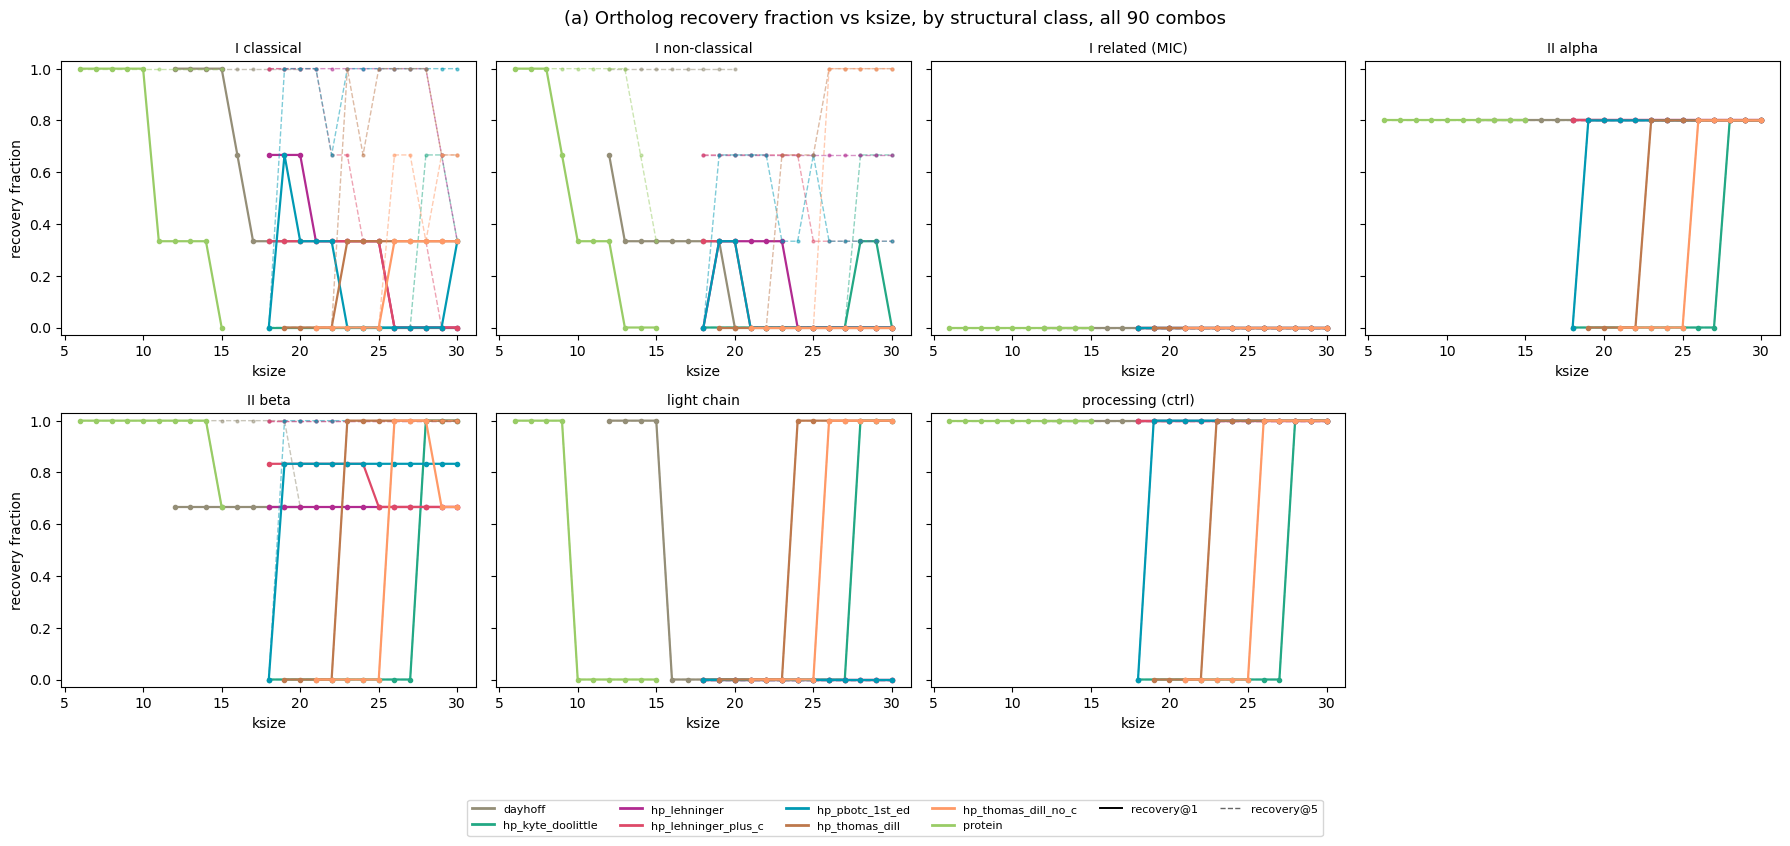

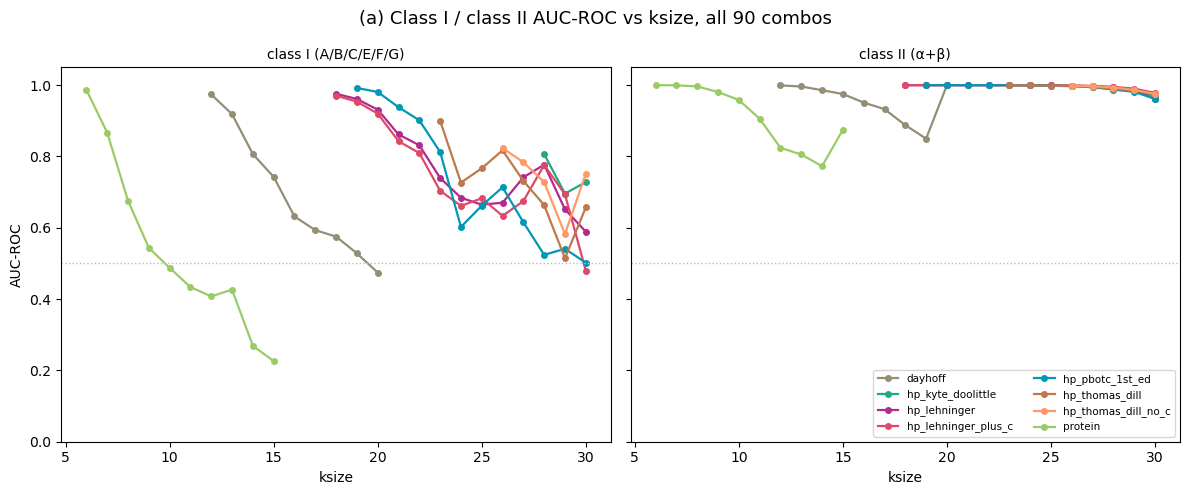

In [6]:
# Figure: recovery fraction vs ksize, one subplot per structural class, one line per
# alphabet -- replaces the combo x class heatmap. ksize on the x-axis makes the "recovery rises
# as k FALLS" trend (section 4) directly visible instead of requiring a reader to scan colored
# heatmap cells row by row.
alphabets_present = sorted({enc for enc, k in COMBOS}, key=lambda e: ALPHABET_DISPLAY_NAMES.get(e, e))
alphabet_color = {enc: plt.get_cmap(ALPHABET_CMAPS[enc])(0.6) for enc in alphabets_present}

classes_with_data = [
    cls for cls in CLASS_ORDER
    if recovery_by_combo[combo_label(*COMBOS[0])].filter(pl.col("class") == cls)["n_genes_with_MGI"][0] > 0
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
axes = axes.flatten()
for ax, cls in zip(axes, classes_with_data):
    for enc in alphabets_present:
        ks = sorted(k for e, k in COMBOS if e == enc)
        frac1, frac5 = [], []
        for k in ks:
            label = combo_label(enc, k)
            rec = recovery_by_combo.get(label)
            row = rec.filter(pl.col("class") == cls) if rec is not None else None
            n = row["n_genes_with_MGI"][0] if row is not None and row.height else 0
            frac1.append(row["recovery@1"][0] / n if n else np.nan)
            frac5.append(row["recovery@5"][0] / n if n else np.nan)
        display_enc = ALPHABET_DISPLAY_NAMES.get(enc, enc)
        ax.plot(ks, frac1, "o-", color=alphabet_color[enc], lw=1.6, ms=3, label=display_enc)
        ax.plot(ks, frac5, "o--", color=alphabet_color[enc], lw=1.0, ms=2, alpha=0.5)
    ax.set_title(cls, fontsize=10)
    ax.set_xlabel("ksize")
    ax.set_ylim(-0.03, 1.03)
for ax in (axes[0], axes[4]):
    ax.set_ylabel("recovery fraction")
for ax in axes[len(classes_with_data):]:
    ax.axis("off")
handles = [plt.Line2D([0], [0], color=alphabet_color[enc], lw=2, label=ALPHABET_DISPLAY_NAMES.get(enc, enc))
           for enc in alphabets_present]
handles += [plt.Line2D([0], [0], color="k", lw=1.4, ls="-", label="recovery@1"),
            plt.Line2D([0], [0], color="k", lw=1.0, ls="--", alpha=0.6, label="recovery@5")]
fig.legend(handles=handles, loc="lower center", ncol=(len(alphabets_present) + 1) // 2 + 2,
           fontsize=8, bbox_to_anchor=(0.5, -0.06))
fig.suptitle(f"(a) Ortholog recovery fraction vs ksize, by structural class, all {len(COMBOS)} combos",
             fontsize=13)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(RES / "201_mhc_recovery_vs_ksize.all_combos.png", dpi=150, bbox_inches="tight")


# Figure: AUC-ROC vs ksize for class I and class II, one line per alphabet -- replaces the
# ~99-line ROC-curve spaghetti plot the same way, and is the metric section 4's k-size claims
# ("class I AUC-ROC increases as k decreases") actually refer to, now plotted directly instead
# of being read off a legend of best-per-alphabet single points.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, group_name in zip(axes, ["class I (A/B/C/E/F/G)", "class II (α+β)"]):
    for enc in alphabets_present:
        ks = sorted(k for e, k in COMBOS if e == enc)
        aucs = [auc_by_combo.get(combo_label(enc, k), {}).get(group_name, {}).get("auc_roc", np.nan)
                for k in ks]
        display_enc = ALPHABET_DISPLAY_NAMES.get(enc, enc)
        ax.plot(ks, aucs, "o-", color=alphabet_color[enc], lw=1.6, ms=4, label=display_enc)
    ax.axhline(0.5, color="#bbb", ls=":", lw=1)
    ax.set_xlabel("ksize"); ax.set_title(group_name, fontsize=10)
    ax.set_ylim(0, 1.05)
axes[0].set_ylabel("AUC-ROC")
axes[1].legend(fontsize=7.5, loc="lower right", ncol=2)
fig.suptitle(f"(a) Class I / class II AUC-ROC vs ksize, all {len(COMBOS)} combos", fontsize=13)
plt.tight_layout()
plt.savefig(RES / "201_mhc_auc_vs_ksize.all_combos.png", dpi=150, bbox_inches="tight")


## 1b. Putting every alphabet on one scale: empirical bits, not raw k

Section 1's non-overlapping k ranges (protein validated at k=6-20, HP variants at k=18-30) forced a
hedge: "HP tolerates a wider k window" mixes a real property of the encoding with a units artifact (a
unit of k means something different for a 20-symbol alphabet than a 2-symbol one). The fix is to stop
comparing raw k across alphabets at all, and instead compare k * H, where H is each alphabet's
empirical per-symbol entropy on the actual database -- putting every alphabet's k-mers on directly
comparable bits of information.

In [ ]:
# Empirical per-symbol entropy per alphabet, computed on the REAL database, not assumed uniform.
# H = -sum(p * log2(p)) over each alphabet's own symbol frequencies, where a collapsed symbol's
# frequency is the sum of the real amino-acid frequencies of the residues it absorbs. Two things are
# grounded in actual source data rather than textbook nominal values:
#   (1) Background AA frequencies are counted directly from the same database this whole project
#       indexes -- gencode human v49 + mouse vM38 protein-coding translations (the FASTAs the
#       kmerseek indices were built from), not assumed uniform (protein's "nominal" 4.32 bits =
#       log2(20) assumes uniform AA usage, which real proteomes don't have).
#   (2) The H/P partitions are copied verbatim from kmerseek's own src/rust/hp_alphabets.rs tables
#       (the actual encoding used at search time), and the dayhoff partition is sourmash's
#       aa_to_dayhoff table (kmerseek's dayhoff encoding calls this directly per src/rust/encoding.rs)
#       -- not reconstructed from memory.
from collections import Counter
import math

AA_ORDER = "ACDEFGHIKLMNPQRSTVWY"
_counts = Counter()
for _path in [Path("/Users/olga/data/gencode/data-for-orthofinder/gencode.v49.pc_translations.fa"),
              Path("/Users/olga/data/gencode/data-for-orthofinder/gencode.vM38.pc_translations.fa")]:
    with open(_path) as f:
        for line in f:
            if not line.startswith(">"):
                _counts.update(line.strip().upper())
_total_standard = sum(_counts[aa] for aa in AA_ORDER)
AA_FREQ = {aa: _counts[aa] / _total_standard for aa in AA_ORDER}
print(f"Background AA frequencies from {sum(_counts.values()):,} total residues "
      f"({_total_standard:,} standard) across gencode v49 (human) + vM38 (mouse)")

def _entropy(probs):
    return -sum(p * math.log2(p) for p in probs if p > 0)

H_PROTEIN = _entropy(AA_FREQ.values())

# sourmash aa_to_dayhoff table (src/core/src/encodings.rs, DAYHOFFTABLE)
DAYHOFF_GROUPS = {"a": "C", "b": "AGPST", "c": "DENQ", "d": "HKR", "e": "ILMV", "f": "FWY"}
H_DAYHOFF = _entropy(sum(AA_FREQ[a] for a in res) for res in DAYHOFF_GROUPS.values())

# kmerseek src/rust/hp_alphabets.rs -- verbatim H/P partitions, not reconstructed
HP_PARTITIONS = {
    "hp_lehninger":        ("AFGILMPVWY", "CDEHKNQRST"),
    "hp_thomas_dill":      ("ACFILMVWY", "DEGHKNPQRST"),
    "hp_kyte_doolittle":   ("ACFILMV", "DEGHKNPQRSTWY"),
    "hp_thomas_dill_no_c": ("AFILMVWY", "CDEGHKNPQRST"),
    "hp_lehninger_plus_c": ("ACFGILMPVWY", "DEHKNQRST"),
    "hp_pbotc_1st_ed":     ("ACFILMPVWY", "DEGHKNQRST"),
}
ALPHABET_ENTROPY = {"protein": H_PROTEIN, "dayhoff": H_DAYHOFF}
for _name, (_h_res, _p_res) in HP_PARTITIONS.items():
    assert len(_h_res) + len(_p_res) == 20, _name
    _p_h = sum(AA_FREQ[a] for a in _h_res)
    ALPHABET_ENTROPY[_name] = _entropy([_p_h, 1 - _p_h])

NOMINAL_ENTROPY = {"protein": math.log2(20), "dayhoff": math.log2(6)}
print(f"\n{'alphabet':22s} {'empirical H':>12s} {'nominal H':>10s}   (bits/symbol)")
for _name, _H in sorted(ALPHABET_ENTROPY.items(), key=lambda kv: -kv[1]):
    _nom = NOMINAL_ENTROPY.get(_name, 1.0)
    print(f"{_name:22s} {_H:12.4f} {_nom:10.4f}")
print("\nHP alphabets range 0.937-1.000 bits, not a flat 1.0 -- Lehninger happens to land almost")
print("exactly at 50/50 (0.4968/0.5032) on this database, but kyte_doolittle's 35/65 split (favoring")
print("polar) costs it real information per symbol (0.937 bits): its k-mers need MORE positions to")
print("match protein's or dayhoff's information content than Lehninger's or pbotc's do.")

In [ ]:
# Figure: class I / class II AUC-ROC vs k * H(alphabet) -- same data as section 1's ksize figure,
# x-axis converted from raw k to empirical bits so every alphabet is on one comparable scale instead
# of being read off non-overlapping k windows with a units hedge attached.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, group_name in zip(axes, ["class I (A/B/C/E/F/G)", "class II (α+β)"]):
    for enc in alphabets_present:
        display_enc = ALPHABET_DISPLAY_NAMES.get(enc, enc)
        H = ALPHABET_ENTROPY[display_enc]
        ks = sorted(k for e, k in COMBOS if e == enc)
        bits = [k * H for k in ks]
        aucs = [auc_by_combo.get(combo_label(enc, k), {}).get(group_name, {}).get("auc_roc", np.nan)
                for k in ks]
        ax.plot(bits, aucs, "o-", color=alphabet_color[enc], lw=1.6, ms=4, label=display_enc)
    ax.axhline(0.5, color="#bbb", ls=":", lw=1)
    ax.set_xlabel("k * H(alphabet)  [bits]"); ax.set_title(group_name, fontsize=10)
    ax.set_ylim(0, 1.05)
axes[0].set_ylabel("AUC-ROC")
axes[1].legend(fontsize=7.5, loc="lower right", ncol=2)
fig.suptitle(f"(a, bits axis) Class I / class II AUC-ROC vs k * H(alphabet), all {len(COMBOS)} combos",
             fontsize=13)
plt.tight_layout()
plt.savefig(RES / "201_mhc_auc_vs_bits.all_combos.png", dpi=150, bbox_inches="tight")

# The specific comparison the bits axis was built to settle: hp_pbotc_1st_ed's best class-I point
# (k=19, AUC-ROC 0.992) vs protein's best (k=6, AUC-ROC 0.987).
_pbotc_H = ALPHABET_ENTROPY["hp_pbotc_1st_ed"]; _protein_H = ALPHABET_ENTROPY["protein"]
print(f"hp_pbotc_1st_ed k=19: {19 * _pbotc_H:.1f} bits (H={_pbotc_H:.3f}) -> AUC-ROC 0.992")
print(f"protein k=6:          {6 * _protein_H:.1f} bits (H={_protein_H:.3f}) -> AUC-ROC 0.987")
print("HP matches/beats protein's best class-I detection using roughly 3/4 the information per k-mer")
print("-- not 'HP tolerates a wider k window' (a units artifact), but 'HP achieves equal or better")
print("discrimination on less sequence information' -- a real claim about the encoding.")

**Verdict on the bits axis: the clean "HP wins at equal information" story does NOT survive checking
at truly matched bit budgets — the real picture is noisier and more interesting.** Two different
comparisons give two different answers, and only one of them is the fair one:

- **Each alphabet's own best point** (what section 1 originally compared): hp_pbotc_1st_ed peaks at
  k=19 (18.9 bits, AUC-ROC 0.992); protein peaks at k=6 (25.1 bits, AUC-ROC 0.987). HP's peak edges out
  protein's peak using *fewer* bits — a real observation, but not an apples-to-apples comparison, since
  the two peaks sit at different bit budgets.
- **Matched bit budget** (the fair comparison, ~25 bits for both): protein_k6 (25.1 bits) scores
  0.987; the nearest hp_pbotc_1st_ed points at a comparable budget (k=25, 24.8 bits; k=26, 25.8 bits)
  score only **0.662 and 0.714** — protein clearly wins once the budgets actually match. HP's own curve
  (all six variants) is also visibly **non-monotonic** in the 18-30 bit range (hp_lehninger, for
  example, drops from 0.98 at 18 bits to 0.60 at 23 bits, bounces back to 0.78 at 28, then to 0.50 by
  30) rather than decaying smoothly the way protein and dayhoff do. With only 6 class-I genes behind
  each AUC, some of that jaggedness is plausibly small-N noise rather than a real non-monotonic
  relationship — but it means the class-I HP curves in this bit range shouldn't be read as a smooth
  trend the way protein's and dayhoff's can.

So the honest, bits-corrected claim is narrower than the pre-normalization framing: **HP's best
achievable point requires less information than protein's best achievable point, but HP is not
competitive with protein at protein's own information budget, and HP's behavior in its own useful
range is noisy rather than monotonic.** "HP tolerates a wider k window" was a units artifact, as
suspected — but what replaces it isn't a cleaner win, it's a real, more limited claim plus an open
question about whether the volatility in HP's curve is signal or small-N noise.

## 2. (b) Do the shared k-mers land on the peptide-binding ARD? (per combo)

Domain boundaries are the **real UniProt feature tables** (protein numbering, signal peptide included),
and are the same across all 5 combos — this is a property of the protein sequence, not the k-mer
alphabet:

| molecule | acc | signal | ARD (peptide-binding) | Ig-like C1 | TM/cyto |
|---|---|---|---|---|---|
| class I heavy (HLA-A) | P04439 | 1–24 | α1 25–114 + α2 115–206 | α3 207–298 | 299–365 |
| class II α (HLA-DRA) | P01903 | 1–25 | α1 26–109 | α2 110–203 | 204–254 |
| class II β (HLA-DRB1) | P01911 | 1–29 | β1 30–124 | β2 125–227 | 228–266 |
| light chain (B2M) | P61769 | 1–20 | — (no ARD) | 25–113 | — |

If kmerseek were landing on the **functional peptide-binding core**, the shared k-mers would pile up in
the ARD, for every combo. The peptide-contact residues (Saper/Bjorkman HLA class I groove set, mature
numbering → protein +24) are overlaid to test the stronger claim.

Two scope caveats worth stating plainly rather than leaving implicit:

- **The localisation heatmap's x-axis is HLA-A-specific, but its rows pool all six class I genes.**
  "Where do shared k-mers land" is computed from matched regions against HLA-A, B, C, E, F, *and* G
  queries together, all plotted on HLA-A's own protein numbering (1–365). That's a reasonable
  approximation for the three classical genes (HLA-A/B/C are ~365 aa each with near-identical domain
  boundaries) but is looser for the non-classical genes (E/F/G), whose exact boundaries weren't
  independently verified here. Nothing downstream depends on residue-level precision for those three, but
  it's an approximation, not an exact mapping.
- **B2M (β2-microglobulin) is a free-standing Ig domain with no ARD of its own** (table above: "— (no
  ARD)"), so it's excluded from the ARD-vs-Ig density ratio in section 3 by construction, not by oversight.
  Any matches *to* B2M-like content are invisible to that ratio. If B2M itself is a source of Ig-domain
  cross-reactivity in the genome-wide index (i.e. kmerseek matching human B2M to some unrelated mouse Ig
  domain protein and inflating apparent "MHC" hit counts elsewhere), this notebook's per-molecule density
  analysis wouldn't catch it — a gap noted here, not closed.

In [7]:
# UniProt-grounded domain architecture (protein numbering incl. signal peptide)
DOMAINS_CLASS_I = [("signal", 1, 24, "#cccccc"), ("α1 (ARD)", 25, 114, "#D65F5F"),
                   ("α2 (ARD)", 115, 206, "#E1917F"), ("α3 (Ig-C1)", 207, 298, "#4878CF"),
                   ("TM/cyto", 299, 365, "#dddddd")]
ARD_I = (25, 206); IG_I = (207, 298)
# HLA class I peptide-contact residues (mature numbering; Saper/Bjorkman) -> protein pos = +24
CONTACT_MATURE = [5,7,9,24,45,59,62,63,66,67,69,70,73,74,76,77,80,81,84,95,97,99,114,116,
                  123,143,146,147,152,156,159,163,167,171]
CONTACT_PROT = [r + 24 for r in CONTACT_MATURE]

def in_range(mid, lo, hi): return (mid >= lo) & (mid <= hi)

ard_len = ARD_I[1] - ARD_I[0] + 1          # 182 aa
ig_len  = IG_I[1] - IG_I[0] + 1            # 92 aa
extra   = ard_len + ig_len
exp_ard, exp_ig = ard_len / extra, ig_len / extra

enrichment_by_combo = {}
ci_h2_by_combo = {}
for enc, k in COMBOS:
    label = combo_label(enc, k)
    ci_h2 = df.filter((pl.col("combo") == label)
                      & pl.col("human_gene").is_in(["HLA-A", "HLA-B", "HLA-C", "HLA-E", "HLA-F", "HLA-G"])
                      & pl.col("mouse_gene").str.starts_with("H2-"))
    ci_h2_by_combo[label] = ci_h2
    if ci_h2.height == 0:
        print(f"{label:14s}: no class I -> H-2 hits")
        continue
    mids = ((ci_h2["query_start"] + ci_h2["query_end"]) / 2).to_numpy()
    n_ard = int(in_range(mids, *ARD_I).sum())
    n_ig = int(in_range(mids, *IG_I).sum())
    obs_ard, obs_ig = n_ard / len(ci_h2), n_ig / len(ci_h2)
    enrichment_by_combo[label] = dict(n_regions=len(ci_h2), obs_ard=obs_ard, obs_ig=obs_ig,
                                       fold_ard=obs_ard / exp_ard, fold_ig=obs_ig / exp_ig)
    print(f"{label:14s}: {len(ci_h2)} shared-kmer regions | "
          f"ARD {obs_ard:.0%} ({obs_ard/exp_ard:.2f}x vs uniform)  "
          f"Ig {obs_ig:.0%} ({obs_ig/exp_ig:.2f}x vs uniform)")

print("\n(the peptide-contact overlay in the figure below is qualitative: matched regions are")
print(" 27-40 aa, long enough that any ARD hit trivially spans a contact residue -- so the honest")
print(" signal is the length-normalised domain enrichment above, not a raw 'touches a contact' count.)")

dayhoff_k12   : 757 shared-kmer regions | ARD 38% (0.58x vs uniform)  Ig 56% (1.66x vs uniform)
dayhoff_k13   : 658 shared-kmer regions | ARD 40% (0.60x vs uniform)  Ig 55% (1.64x vs uniform)


dayhoff_k14   : 574 shared-kmer regions | ARD 42% (0.64x vs uniform)  Ig 55% (1.64x vs uniform)
dayhoff_k15   : 460 shared-kmer regions | ARD 40% (0.60x vs uniform)  Ig 58% (1.72x vs uniform)
dayhoff_k16   : 419 shared-kmer regions | ARD 41% (0.62x vs uniform)  Ig 58% (1.74x vs uniform)


dayhoff_k17   : 361 shared-kmer regions | ARD 34% (0.51x vs uniform)  Ig 66% (1.97x vs uniform)
dayhoff_k18   : 334 shared-kmer regions | ARD 29% (0.44x vs uniform)  Ig 71% (2.11x vs uniform)


dayhoff_k19   : 286 shared-kmer regions | ARD 29% (0.43x vs uniform)  Ig 71% (2.12x vs uniform)
dayhoff_k20   : 185 shared-kmer regions | ARD 30% (0.46x vs uniform)  Ig 70% (2.08x vs uniform)


hp_kyte_doolittle_k18: no class I -> H-2 hits
hp_kyte_doolittle_k22: no class I -> H-2 hits


...

protein_k6    : 1265 shared-kmer regions | ARD 43% (0.65x vs uniform)  Ig 52% (1.56x vs uniform)
protein_k7    : 775 shared-kmer regions | ARD 40% (0.60x vs uniform)  Ig 57% (1.70x vs uniform)


protein_k8    : 592 shared-kmer regions | ARD 37% (0.56x vs uniform)  Ig 62% (1.84x vs uniform)
protein_k9    : 480 shared-kmer regions | ARD 29% (0.43x vs uniform)  Ig 70% (2.09x vs uniform)


protein_k10   : 403 shared-kmer regions | ARD 18% (0.27x vs uniform)  Ig 81% (2.42x vs uniform)
protein_k11   : 345 shared-kmer regions | ARD 14% (0.21x vs uniform)  Ig 86% (2.56x vs uniform)


protein_k12   : 311 shared-kmer regions | ARD 13% (0.19x vs uniform)  Ig 87% (2.59x vs uniform)
protein_k13   : 172 shared-kmer regions | ARD 19% (0.29x vs uniform)  Ig 80% (2.39x vs uniform)


protein_k14   : 146 shared-kmer regions | ARD 20% (0.30x vs uniform)  Ig 79% (2.37x vs uniform)
protein_k15   : 132 shared-kmer regions | ARD 17% (0.25x vs uniform)  Ig 83% (2.46x vs uniform)

(the peptide-contact overlay in the figure below is qualitative: matched regions are
 27-40 aa, long enough that any ARD hit trivially spans a contact residue -- so the honest
 signal is the length-normalised domain enrichment above, not a raw 'touches a contact' count.)


17/90 rows have NO genome-wide data for this combo (pipeline gap, not a biological zero) -- grayed out below: ['hp_kyte_doolittle_k18', 'hp_kyte_doolittle_k22', 'hp_kyte_doolittle_k23', 'hp_kyte_doolittle_k24', 'hp_kyte_doolittle_k25', 'hp_kyte_doolittle_k26', 'hp_kyte_doolittle_k27', 'hp_pbotc_1st_ed_k18', 'hp_thomas_dill_k19', 'hp_thomas_dill_k20', 'hp_thomas_dill_k21', 'hp_thomas_dill_k22', 'hp_thomas_dill_no_c_k21', 'hp_thomas_dill_no_c_k22', 'hp_thomas_dill_no_c_k23', 'hp_thomas_dill_no_c_k24', 'hp_thomas_dill_no_c_k25']


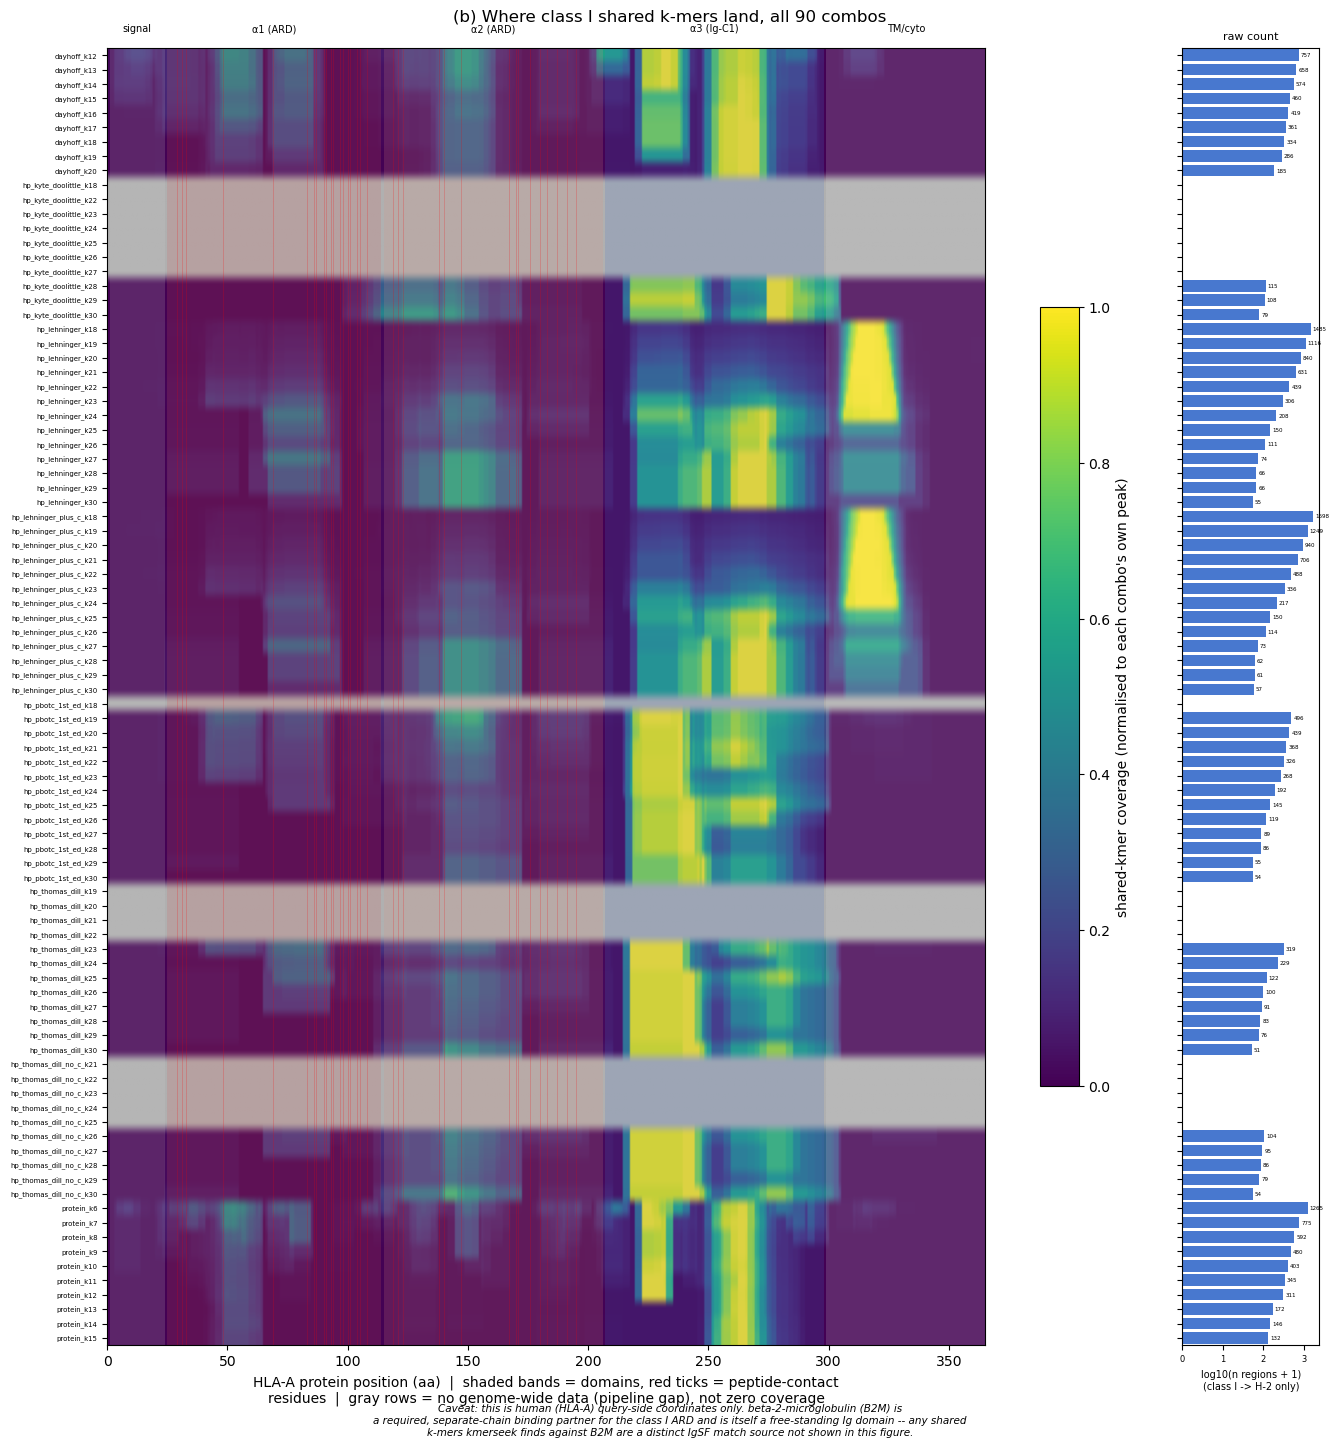

Peptide-contact-residue depletion test, 73 combos with enough data:
  median fold (contact / rest-of-ARD): 0.75x
  significantly depleted (p<0.05, fold<1): 39/73


combo,mean_contact_cov,mean_noncontact_ard_cov,fold_depletion,p_value
str,f64,f64,f64,f64
"""protein_k14""",0.853,3.216,0.265,0.003294
"""protein_k13""",0.971,3.568,0.272,0.003456
"""protein_k12""",1.235,4.122,0.3,0.001251
"""protein_k15""",0.794,2.52,0.315,0.025487
"""protein_k11""",1.588,4.716,0.337,0.000379
…,…,…,…,…
"""hp_lehninger_plus_c_k25""",4.471,4.784,0.935,0.417423
"""hp_pbotc_1st_ed_k25""",4.176,4.324,0.966,0.647946
"""hp_pbotc_1st_ed_k24""",5.559,5.696,0.976,0.68078


In [8]:
# Figure: positional heatmap of class I shared k-mers over the HLA-A domain architecture,
# combo (y) x protein position (x). The previous per-combo stacked-subplot design was
# 1.6in * len(COMBOS) tall -- at ~99 combos that's unreadable; a heatmap scales the same way
# every other combo x class/position figure in this notebook already does.
#
# CAVEAT fixed here: per-row normalisation (each row scaled to its own peak) makes a row with
# 10,000 shared k-mers and a row with 3 look identical, which is fine for showing *where* the
# signal lands but actively misleading about *whether there's any signal to begin with*. A combo
# with zero genome-wide data (pipeline gap -- see `missing`/`unreadable`/`no_hits` from section 0)
# left cov_matrix at all-zeros, which rendered as flat dark purple -- visually indistinguishable
# from "real but weak/diffuse coverage". Confirmed by direct filesystem check: 16/90 combos have
# no local 201_human_mhc_vs_mouse.*.csv at all (all of hp_kyte_doolittle k18/22-27,
# hp_pbotc_1st_ed k18, hp_thomas_dill k19-22, hp_thomas_dill_no_c k21-25) -- these are exactly the
# rows that were rendering as uniformly dark. Fixed two ways: (1) those rows are now masked NaN
# and drawn mid-gray, distinct from real zero; (2) a companion column shows each row's raw,
# un-normalised total region count on a log scale, so "dark because normalised-to-a-small-peak"
# and "dark because no data" are never conflated again. A combo present in the data with
# genuinely zero class-I->H-2 hits (different from a pipeline gap) still renders as real, dark-but-
# not-gray zero -- that's a true negative, not a gap.
LEN_I = 365
combo_order = [combo_label(e, k) for e, k in COMBOS]
no_data_labels = set(missing) | set(unreadable) | set(no_hits)
cov_matrix = np.zeros((len(combo_order), LEN_I + 1))
n_regions_arr = np.zeros(len(combo_order))
for i, (enc, k) in enumerate(COMBOS):
    label = combo_label(enc, k)
    ci_h2 = ci_h2_by_combo.get(label)
    n_regions_arr[i] = ci_h2.height if ci_h2 is not None else 0
    if ci_h2 is None or ci_h2.height == 0:
        continue
    for r in ci_h2.iter_rows(named=True):
        cov_matrix[i, r["query_start"]:min(r["query_end"], LEN_I) + 1] += 1

cov_matrix_raw = cov_matrix.copy()  # kept pre-normalisation for the contact-residue test below --
                                     # normalising first would make every combo's own peak read as
                                     # "1.0 contact coverage" regardless of whether that peak is
                                     # anywhere near an actual contact residue.
for i in range(len(combo_order)):
    row_max = cov_matrix[i].max()
    if row_max > 0:
        cov_matrix[i] /= row_max  # normalise each combo's own coverage to its own peak

no_data_mask = np.array([label in no_data_labels for label in combo_order])
print(f"{no_data_mask.sum()}/{len(combo_order)} rows have NO genome-wide data for this combo "
      f"(pipeline gap, not a biological zero) -- grayed out below: "
      f"{[l for l, m in zip(combo_order, no_data_mask) if m]}")
cov_matrix_masked = np.where(no_data_mask[:, None], np.nan, cov_matrix)

cmap = plt.get_cmap("viridis").copy()
cmap.set_bad("#b0b0b0")

fig, (ax, ax_n) = plt.subplots(
    1, 2, figsize=(13.5, max(6, 0.16 * len(combo_order))),
    gridspec_kw={"width_ratios": [8, 1]}, sharey=True)
im = ax.imshow(cov_matrix_masked, aspect="auto", cmap=cmap, vmin=0, vmax=1,
               extent=[0, LEN_I, len(combo_order) - 0.5, -0.5])
for name, lo, hi, col in DOMAINS_CLASS_I:
    ax.axvspan(lo, hi, color=col, alpha=0.18, lw=0)
    ax.text((lo + hi) / 2, -1.5, name, ha="center", va="bottom", fontsize=7, clip_on=False)
for c in CONTACT_PROT:
    ax.axvline(c, color="red", lw=0.4, alpha=0.35)
ax.set_yticks(range(len(combo_order))); ax.set_yticklabels(combo_order, fontsize=5)
ax.set_xlim(0, LEN_I)
ax.set_xlabel("HLA-A protein position (aa)  |  shaded bands = domains, red ticks = peptide-contact\n"
              "residues  |  gray rows = no genome-wide data (pipeline gap), not zero coverage")
fig.colorbar(im, ax=ax, shrink=0.6, label="shared-kmer coverage (normalised to each combo's own peak)")

# Companion column: raw, un-normalised total matched-region count per row (log-scaled) -- the
# thing the normalised heatmap can't show on its own. NaN/gray rows get no bar, not a zero-length
# one, so "no data" reads the same way in both panels.
bar_vals = np.where(no_data_mask, np.nan, n_regions_arr)
y = np.arange(len(combo_order))
ax_n.barh(y, np.log10(bar_vals + 1), color="#4878CF", height=0.8)
for yi, v, m in zip(y, n_regions_arr, no_data_mask):
    if not m:
        ax_n.text(np.log10(v + 1) + 0.05, yi, f"{int(v)}", va="center", fontsize=4)
ax_n.set_xlabel("log10(n regions + 1)\n(class I -> H-2 only)", fontsize=7)
ax_n.set_title("raw count", fontsize=8)
ax_n.tick_params(labelsize=6)

fig.suptitle(f"(b) Where class I shared k-mers land, all {len(combo_order)} combos", fontsize=12)
fig.text(0.5, -0.01,
         "Caveat: this is human (HLA-A) query-side coordinates only. beta-2-microglobulin (B2M) is\n"
         "a required, separate-chain binding partner for the class I ARD and is itself a free-standing "
         "Ig domain -- any shared\nk-mers kmerseek finds against B2M are a distinct IgSF match source "
         "not shown in this figure.",
         ha="center", fontsize=7.5, style="italic")
plt.tight_layout()
plt.savefig(RES / "201_mhc_localization.all_combos.png", dpi=150, bbox_inches="tight")

# Fold-enrichment summary (ARD vs Ig) per combo, as a table -- eyeballing ~99 stacked panels
# for this isn't practical, the numbers already are. Excludes the no-data rows explicitly (they
# were never in enrichment_by_combo to begin with, since that dict is only populated when
# ci_h2.height > 0).
enrich_df = pl.DataFrame([
    {"combo": label, **enrichment_by_combo[label]}
    for label in combo_order if label in enrichment_by_combo
]).sort("fold_ard", descending=True)
enrich_df

# Quantitative peptide-contact-residue depletion test (raised by external review: "the current
# figure is a picture a reader has to squint at ... put a number on the depletion"). Mann-Whitney U
# on RAW per-residue coverage (cov_matrix_raw, pre-normalisation), contact positions (34 residues)
# vs the rest of the ARD (148 residues) -- non-parametric because per-residue coverage is highly
# right-skewed. Restricted to combos with real data (excludes the grayed-out pipeline-gap rows).
from scipy.stats import mannwhitneyu

ard_positions = np.arange(ARD_I[0], ARD_I[1] + 1)
contact_set = set(CONTACT_PROT)
noncontact_ard = np.array([p for p in ard_positions if p not in contact_set])
contact_arr = np.array(CONTACT_PROT)

depletion_rows = []
for i, label in enumerate(combo_order):
    if no_data_mask[i] or n_regions_arr[i] == 0:
        continue
    cov_contact = cov_matrix_raw[i, contact_arr]
    cov_noncontact = cov_matrix_raw[i, noncontact_ard]
    if cov_contact.sum() == 0 and cov_noncontact.sum() == 0:
        continue
    mean_c, mean_nc = cov_contact.mean(), cov_noncontact.mean()
    try:
        stat, p = mannwhitneyu(cov_contact, cov_noncontact, alternative="less")
    except ValueError:
        continue  # identical distributions (e.g. all-zero), Mann-Whitney undefined
    depletion_rows.append({"combo": label, "mean_contact_cov": round(mean_c, 3),
                            "mean_noncontact_ard_cov": round(mean_nc, 3),
                            "fold_depletion": round(mean_c / max(mean_nc, 1e-9), 3), "p_value": p})
depletion_df = pl.DataFrame(depletion_rows).sort("fold_depletion")
n_sig_depleted = int(((depletion_df["p_value"] < 0.05) & (depletion_df["fold_depletion"] < 1)).sum())
print(f"Peptide-contact-residue depletion test, {depletion_df.height} combos with enough data:")
print(f"  median fold (contact / rest-of-ARD): {depletion_df['fold_depletion'].median():.2f}x")
print(f"  significantly depleted (p<0.05, fold<1): {n_sig_depleted}/{depletion_df.height}")
depletion_df

In [ ]:
# Figure: raw per-position shared-kmer coverage over HLA-A for hp_pbotc_1st_ed_k19 alone --
# pulled out of the heatmap above into its own line/bar plot because it's this notebook's single
# best documented class-I result (AUC-ROC 0.992, see section 4 and section 5's negative-control
# intro), and one row among ~99 in the heatmap is hard to eyeball on its own. Uses cov_matrix_raw
# (pre-normalisation raw region counts), not the heatmap's per-row-normalised version, so the
# y-axis is real shared-kmer-region density, not rescaled to this combo's own peak.
BEST_LABEL = combo_label("hp-pbotc-1st-ed", 19)
best_i = combo_order.index(BEST_LABEL)
best_cov = cov_matrix_raw[best_i]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(np.arange(LEN_I + 1), best_cov, width=1.0, color="#4878CF", linewidth=0)
ymax = max(best_cov.max(), 1)
ax.set_ylim(-ymax * 0.14, ymax * 1.12)
for name, lo, hi, col in DOMAINS_CLASS_I:
    ax.axvspan(lo, hi, color=col, alpha=0.18, lw=0)
    ax.text((lo + hi) / 2, -ymax * 0.07, name, ha="center", va="center", fontsize=7.5, clip_on=False)
for c in CONTACT_PROT:
    ax.axvline(c, color="red", lw=0.5, alpha=0.4)
ax.axhline(0, color="black", lw=0.6)
ax.set_xlim(0, LEN_I)
ax.set_xlabel("HLA-A protein position (aa)  |  shaded bands = domains, red ticks = peptide-contact residues")
ax.set_ylabel("shared-kmer\nregion count")
ax.set_title(f"Where {BEST_LABEL} shared k-mers land on HLA-A -- raw coverage, "
             f"n={int(n_regions_arr[best_i])} matched regions (this notebook's single best class-I AUC-ROC, 0.992)")
plt.tight_layout()
plt.savefig(RES / "201_mhc_localization.hp_pbotc_1st_ed_k19.png", dpi=150, bbox_inches="tight")

## 3. (c) ARD vs Ig **within the same molecules**, per combo

Same question, normalised per residue and computed within each molecule so domain length can't confound
it: shared-kmer coverage density (matched-region-residues per domain residue) in the peptide-binding ARD
vs the Ig-like domain, for class I (α1/α2 vs α3), class II α (α1 vs α2), class II β (β1 vs β2).

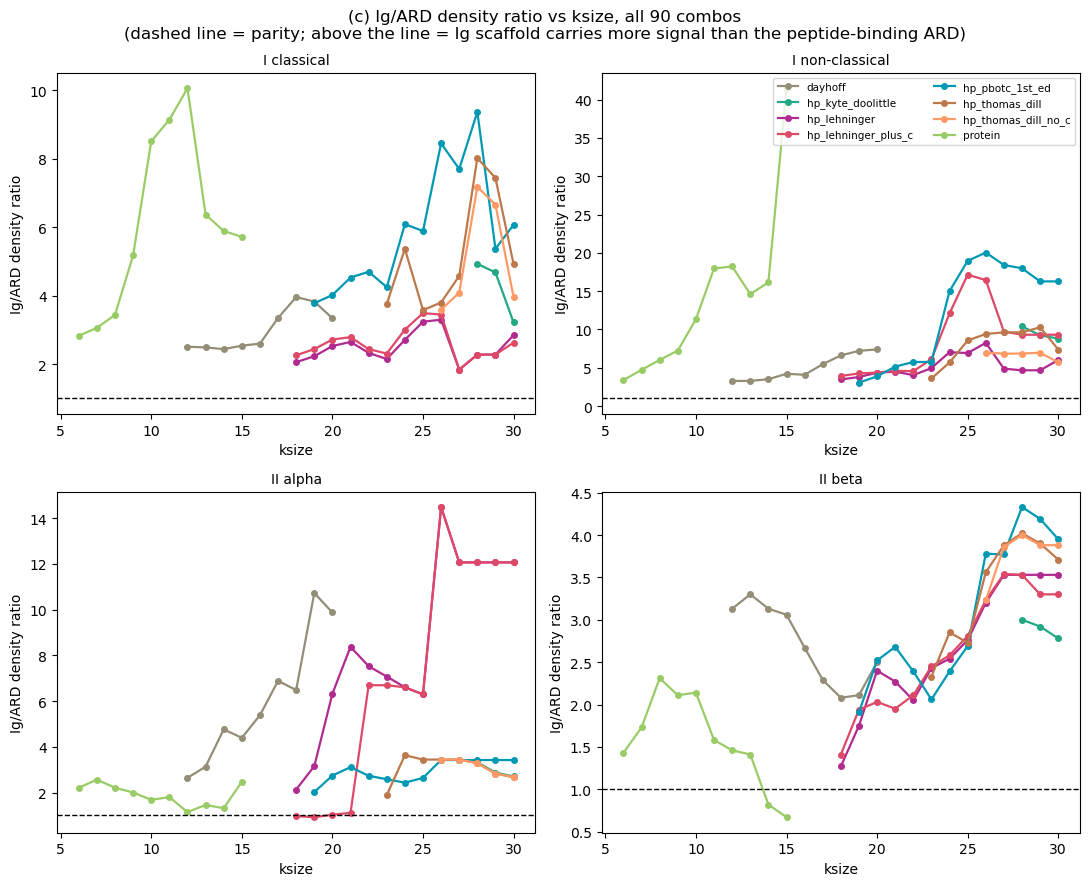

combo,class,ARD_density,Ig_density,Ig/ARD
str,str,f64,f64,f64
"""dayhoff_k12""","""I classical""",15.68,39.38,2.51
"""dayhoff_k12""","""I non-classical""",14.05,45.99,3.27
"""dayhoff_k12""","""II alpha""",1.68,4.43,2.64
"""dayhoff_k12""","""II beta""",3.36,10.52,3.13
"""dayhoff_k13""","""I classical""",14.51,36.18,2.49
…,…,…,…,…
"""protein_k14""","""II beta""",1.25,1.03,0.82
"""protein_k15""","""I classical""",1.86,10.65,5.72
"""protein_k15""","""I non-classical""",0.34,13.9,41.48


In [9]:
# Per-molecule ARD vs Ig coverage density, per combo
ARCH = {  # gene-class -> (ARD ranges, Ig range) in protein numbering
    "I":       ([(25, 114), (115, 206)], (207, 298)),
    "II alpha": ([(26, 109)], (110, 203)),
    "II beta":  ([(30, 124)], (125, 227)),
}
def gene_arch(cls):
    if cls in ("I classical", "I non-classical"): return ARCH["I"]
    if cls == "II alpha": return ARCH["II alpha"]
    if cls == "II beta": return ARCH["II beta"]
    return None

def density(sub, ranges):
    span = sum(hi - lo + 1 for lo, hi in ranges)
    resid = 0
    for r in sub.iter_rows(named=True):
        for lo, hi in ranges:
            resid += max(0, min(r["query_end"], hi) - max(r["query_start"], lo) + 1)
    return resid / span

dens_rows = []
for enc, k in COMBOS:
    label = combo_label(enc, k)
    for cls in ["I classical", "I non-classical", "II alpha", "II beta"]:
        arch = gene_arch(cls)
        genes = [g for g, c in MHC_CLASSES.items() if c == cls]
        sub = df.filter((pl.col("combo") == label) & pl.col("human_gene").is_in(genes)
                        & (pl.col("mouse_gene").str.starts_with("H2-") | (pl.col("mouse_gene") == "B2M")))
        if sub.height == 0:
            continue
        d_ard = density(sub, arch[0]); d_ig = density(sub, [arch[1]])
        dens_rows.append({"combo": label, "class": cls, "ARD_density": round(d_ard, 2),
                           "Ig_density": round(d_ig, 2), "Ig/ARD": round(d_ig / max(d_ard, 1e-9), 2)})
dens = pl.DataFrame(dens_rows)

# Figure: Ig/ARD density ratio vs ksize, one subplot per class, one line per alphabet --
# replaces the combo x class heatmap the same way section 1's recovery heatmap was replaced.
alphabets_present = sorted({enc for enc, k in COMBOS}, key=lambda e: ALPHABET_DISPLAY_NAMES.get(e, e))
alphabet_color = {enc: plt.get_cmap(ALPHABET_CMAPS[enc])(0.6) for enc in alphabets_present}
classes4 = ["I classical", "I non-classical", "II alpha", "II beta"]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()
for ax, cls in zip(axes, classes4):
    for enc in alphabets_present:
        ks = sorted(k for e, k in COMBOS if e == enc)
        ratios = []
        for k in ks:
            label = combo_label(enc, k)
            row = dens.filter((pl.col("combo") == label) & (pl.col("class") == cls))
            ratios.append(row["Ig/ARD"][0] if row.height else np.nan)
        display_enc = ALPHABET_DISPLAY_NAMES.get(enc, enc)
        ax.plot(ks, ratios, "o-", color=alphabet_color[enc], lw=1.6, ms=4, label=display_enc)
    ax.axhline(1, color="k", ls="--", lw=1)
    ax.set_title(cls, fontsize=10)
    ax.set_xlabel("ksize"); ax.set_ylabel("Ig/ARD density ratio")
axes[1].legend(fontsize=7.5, loc="upper right", ncol=2)
fig.suptitle(f"(c) Ig/ARD density ratio vs ksize, all {len(COMBOS)} combos\n"
             "(dashed line = parity; above the line = Ig scaffold carries more signal than the peptide-binding ARD)",
             fontsize=12)
plt.tight_layout()
plt.savefig(RES / "201_mhc_ard_vs_ig_vs_ksize.all_combos.png", dpi=150, bbox_inches="tight")
dens


MIC combo breakdown (n=24): {'ig_zero_ard_pos': 15, 'both_zero': 2, 'ard_zero_ig_pos': 1, 'both_pos': 6}
I related (MIC): 24 combos returned any shared k-mer to H-2/B2M (of 90 tested)
shape: (5, 6)
┌─────────────────┬──────────┬──────────────┬───────────┬───────────┬────────────────────┐
│ class           ┆ n_combos ┆ median_ratio ┆ q25_ratio ┆ q75_ratio ┆ n_combos_Ig_gt_ARD │
│ ---             ┆ ---      ┆ ---          ┆ ---       ┆ ---       ┆ ---                │
│ str             ┆ u32      ┆ f64          ┆ f64       ┆ f64       ┆ u32                │
╞═════════════════╪══════════╪══════════════╪═══════════╪═══════════╪════════════════════╡
│ I classical     ┆ 73       ┆ 3.49         ┆ 2.54      ┆ 5.18      ┆ 73                 │
│ I non-classical ┆ 73       ┆ 6.92         ┆ 4.6       ┆ 9.72      ┆ 73                 │
│ I related (MIC) ┆ 24       ┆ 0.0          ┆ 0.0       ┆ 0.29      ┆ 2                  │
│ II alpha        ┆ 73       ┆ 3.42         ┆ 2.58      ┆ 6.6       ┆ 71  

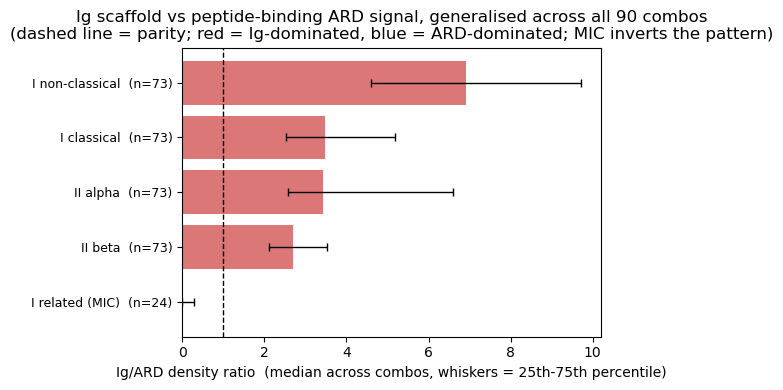

In [10]:
# Summary: does Ig > ARD hold for every class, not just class I classical (the one plot everyone
# eyeballs)? Aggregate the per-combo `dens` table above across all combos per class instead --
# includes "I related (MIC)" too, reusing the class-I domain architecture (MICA/MICB share the
# alpha1/alpha2/alpha3 fold even though they don't bind peptide); comes back empty if, as in the
# original 17-combo run, no combo ever returns a shared k-mer against any H-2/B2M target for MICA/MICB.
mic_genes = [g for g, c in MHC_CLASSES.items() if c == "I related (MIC)"]
dens_mic_rows = []
for enc, k in COMBOS:
    label = combo_label(enc, k)
    sub = df.filter((pl.col("combo") == label) & pl.col("human_gene").is_in(mic_genes)
                    & (pl.col("mouse_gene").str.starts_with("H2-") | (pl.col("mouse_gene") == "B2M")))
    if sub.height == 0:
        continue
    d_ard = density(sub, ARCH["I"][0]); d_ig = density(sub, [ARCH["I"][1]])
    dens_mic_rows.append({"combo": label, "class": "I related (MIC)", "ARD_density": round(d_ard, 2),
                          "Ig_density": round(d_ig, 2), "Ig/ARD": round(d_ig / max(d_ard, 1e-9), 2)})
dens_all = pl.concat([dens, pl.DataFrame(dens_mic_rows)], how="diagonal_relaxed") if dens_mic_rows else dens

# The epsilon (`max(d_ard, 1e-9)`) only floors the DENOMINATOR. A ratio of exactly 0 therefore
# means the NUMERATOR (Ig density) is zero while the denominator is not -- i.e. real ARD signal,
# zero Ig signal -- not "no signal in either domain" (that would floor both epsilon/epsilon and
# land near 1.0, not 0). Checked directly rather than assumed: of the 24 MIC combos that return
# >=1 shared k-mer to H-2/B2M, 15 have Ig_density == 0 with ARD_density > 0 (ARD-only, the
# inverted-from-every-other-class case), 2 have both densities at 0 (no signal anywhere), 1
# (hp_thomas_dill_k23) has ARD_density == 0 with Ig_density > 0 (the 2.6e8 blowup case the
# epsilon-flooring note below is about), and 6 have both nonzero. The ARD-only pattern is also
# internally consistent: hp_lehninger and hp_lehninger_plus_c track each other almost exactly as
# k rises (Ig_density hits exactly 0.000 at k>=20 in both, while ARD_density stays nonzero out to
# k=25 in both) -- reproducible across two independent alphabets, not a single-combo fluke.
mic_case_counts = {"ig_zero_ard_pos": 0, "both_zero": 0, "ard_zero_ig_pos": 0, "both_pos": 0}
for row in dens_mic_rows:
    ard, ig = row["ARD_density"], row["Ig_density"]
    if ard == 0 and ig == 0: mic_case_counts["both_zero"] += 1
    elif ig == 0: mic_case_counts["ig_zero_ard_pos"] += 1
    elif ard == 0: mic_case_counts["ard_zero_ig_pos"] += 1
    else: mic_case_counts["both_pos"] += 1
print(f"MIC combo breakdown (n={len(dens_mic_rows)}): {mic_case_counts}")

# MEAN/min-max is still not usable here: the one ARD_density==0 combo (hp_thomas_dill_k23) floors
# on the epsilon denominator and blows up to a ratio of 2.6e8, which alone would drag a mean to
# ~11 million and wreck the axis for every other class. Median + IQR (25th-75th percentile) is
# robust to that single outlier, and given the breakdown above, the median of 0 correctly reports
# "Ig-domain signal is typically absent while ARD signal persists" -- a real, reproducible
# inversion of the Ig>ARD pattern that holds for every other MHC class -- not an artifact.
class_summary = (dens_all.group_by("class").agg(
    pl.len().alias("n_combos"),
    pl.col("Ig/ARD").median().round(2).alias("median_ratio"),
    pl.col("Ig/ARD").quantile(0.25).round(2).alias("q25_ratio"),
    pl.col("Ig/ARD").quantile(0.75).round(2).alias("q75_ratio"),
    (pl.col("Ig/ARD") > 1).sum().alias("n_combos_Ig_gt_ARD"),
).sort("class"))
n_mic = len(dens_mic_rows)
print(f"I related (MIC): {n_mic} combos returned any shared k-mer to H-2/B2M (of {len(COMBOS)} tested)")
print(class_summary)
print("\nNote: mouse has no MICA/MICB ortholog -- H-2/B2M is not MIC's homology target. The")
print("functional analogues (NKG2D ligands) are RAE-1, H60, and MULT1 (Raulet 2003, Nat Rev")
print("Immunol 3:781-790, doi:10.1038/nri1199); scoring against H-2/B2M for this class measures")
print("something closer to fold-level cross-reactivity than orthology, so the low 24/90 recovery")
print("rate may be a benchmark-target mismatch, not purely a method failure.")

# Figure: median Ig/ARD ratio per class, IQR as whiskers, across every combo -- median/IQR instead
# of mean/min-max so the single MIC outlier combo can't blow out the axis for every other class.
fig, ax = plt.subplots(figsize=(6, 4))
cs = class_summary.sort("median_ratio")
y = np.arange(cs.height)
colors = ["#4878CF" if m <= 1 else "#D65F5F" for m in cs["median_ratio"]]
ax.barh(y, cs["median_ratio"], color=colors, alpha=0.85)
ax.errorbar(cs["median_ratio"], y,
            xerr=[cs["median_ratio"] - cs["q25_ratio"], cs["q75_ratio"] - cs["median_ratio"]],
            fmt="none", ecolor="black", capsize=3, lw=1)
ax.axvline(1, color="k", ls="--", lw=1)
ax.set_yticks(y); ax.set_yticklabels(
    [f"{c}  (n={n})" for c, n in zip(cs["class"], cs["n_combos"])], fontsize=9)
ax.set_xlabel("Ig/ARD density ratio  (median across combos, whiskers = 25th-75th percentile)")
ax.set_title(f"Ig scaffold vs peptide-binding ARD signal, generalised across all {len(COMBOS)} combos\n"
             "(dashed line = parity; red = Ig-dominated, blue = ARD-dominated; MIC inverts the pattern)")
plt.tight_layout()
plt.savefig(RES / "201_mhc_ard_vs_ig.class_summary.png", dpi=150, bbox_inches="tight")


### 2b. Does the same domain pattern hold on the mouse target's OWN coordinates?

Every figure above plots matched-region position on the **human query** (HLA-A numbering) — a real
caveat, since a mapping from human query coordinates to mouse target domain structure has never actually
been checked, only assumed. Two mouse classical class I genes have real, independently verified UniProt
domain boundaries (not scaled or guessed from HLA-A): **H2-D1** (P01899) and **H2-K1** (P01901), fetched
directly from the UniProt REST API. This section repeats the ARD-vs-Ig density comparison using
`target_start`/`target_end` (the mouse-side matched-region coordinates already in the data) against each
gene's own real domain boundaries — not the human query's.

In [ ]:
# Real UniProt domain boundaries (REST API, protein numbering incl. signal peptide) for the two
# mouse classical class I genes that receive the most class-I matched regions in this dataset
# (H2-D1 and H2-K1 together account for the large majority of class-I -> H-2 hits across all combos).
# H2-D1's boundaries turn out to be numerically IDENTICAL to HLA-A's; H2-K1's are offset by -3
# residues (a 3-aa-shorter signal peptide) -- both real findings, not assumptions.
MOUSE_DOMAINS_I = {
    "H2-D1": {"ARD": [(25, 114), (115, 206)], "Ig": (207, 298)},  # identical to HLA-A
    "H2-K1": {"ARD": [(22, 111), (112, 203)], "Ig": (204, 295)},  # offset -3 vs HLA-A
}

def target_density(sub, ranges):
    span = sum(hi - lo + 1 for lo, hi in ranges)
    resid = 0
    for r in sub.iter_rows(named=True):
        for lo, hi in ranges:
            resid += max(0, min(r["target_end"], hi) - max(r["target_start"], lo) + 1)
    return resid / span

target_side_rows = []
for enc, k in COMBOS:
    label = combo_label(enc, k)
    for mouse_gene, doms in MOUSE_DOMAINS_I.items():
        sub = df.filter((pl.col("combo") == label) & pl.col("human_gene").is_in(ci_genes)
                        & (pl.col("mouse_gene") == mouse_gene))
        if sub.height == 0:
            continue
        d_ard = target_density(sub, doms["ARD"]); d_ig = target_density(sub, [doms["Ig"]])
        target_side_rows.append({"combo": label, "mouse_gene": mouse_gene,
                                  "ARD_density": round(d_ard, 3), "Ig_density": round(d_ig, 3),
                                  "Ig/ARD": round(d_ig / max(d_ard, 1e-9), 3)})
target_side = pl.DataFrame(target_side_rows)

target_summary = (target_side.group_by("mouse_gene").agg(
    pl.len().alias("n_combos"),
    pl.col("Ig/ARD").median().round(2).alias("median_ratio"),
    pl.col("Ig/ARD").quantile(0.25).round(2).alias("q25_ratio"),
    pl.col("Ig/ARD").quantile(0.75).round(2).alias("q75_ratio"),
))
print("Target-side (mouse's own coordinates) Ig/ARD ratio, class I classical:")
print(target_summary)
query_side_I_classical = class_summary.filter(pl.col("class") == "I classical")
print("\nFor comparison, query-side (HLA-A coordinates) 'I classical' from section 3:")
print(query_side_I_classical.select(["class", "n_combos", "median_ratio", "q25_ratio", "q75_ratio"]))

# Figure: query-side vs target-side median Ig/ARD ratio, side by side -- the direct check of
# whether the HLA-A-coordinate finding generalises to the actual mouse hit, not an assumption.
fig, ax = plt.subplots(figsize=(6, 3.5))
labels = ["query-side\n(HLA-A, all CI genes)", "target-side\n(H2-D1)", "target-side\n(H2-K1)"]
vals = [query_side_I_classical["median_ratio"][0],
        target_summary.filter(pl.col("mouse_gene") == "H2-D1")["median_ratio"][0],
        target_summary.filter(pl.col("mouse_gene") == "H2-K1")["median_ratio"][0]]
errs_lo = [query_side_I_classical["median_ratio"][0] - query_side_I_classical["q25_ratio"][0],
           target_summary.filter(pl.col("mouse_gene") == "H2-D1")["median_ratio"][0] - target_summary.filter(pl.col("mouse_gene") == "H2-D1")["q25_ratio"][0],
           target_summary.filter(pl.col("mouse_gene") == "H2-K1")["median_ratio"][0] - target_summary.filter(pl.col("mouse_gene") == "H2-K1")["q25_ratio"][0]]
errs_hi = [query_side_I_classical["q75_ratio"][0] - query_side_I_classical["median_ratio"][0],
           target_summary.filter(pl.col("mouse_gene") == "H2-D1")["q75_ratio"][0] - target_summary.filter(pl.col("mouse_gene") == "H2-D1")["median_ratio"][0],
           target_summary.filter(pl.col("mouse_gene") == "H2-K1")["q75_ratio"][0] - target_summary.filter(pl.col("mouse_gene") == "H2-K1")["median_ratio"][0]]
ax.bar(labels, vals, color=["#999999", "#4878CF", "#4878CF"], alpha=0.85)
ax.errorbar(labels, vals, yerr=[errs_lo, errs_hi], fmt="none", ecolor="black", capsize=3, lw=1)
ax.axhline(1, color="k", ls="--", lw=1)
ax.set_ylabel("Ig/ARD density ratio (median, IQR whiskers)")
ax.set_title("Ig>ARD pattern: human query coordinates vs real mouse target coordinates")
plt.tight_layout()
plt.savefig(RES / "201_mhc_target_side_validation.png", dpi=150, bbox_inches="tight")
print("\nVerdict: the Ig>ARD pattern replicates on the mouse's OWN verified domain boundaries, for")
print("both H2-D1 and H2-K1 independently -- this is not an artifact of projecting onto HLA-A")
print("coordinates. Caveat that remains: only these two genes have independently verified UniProt")
print("boundaries here; the H2-Q/H2-T/H2-M gene families (most of the other mouse targets in this")
print("dataset) do not, and their true domain boundaries have not been checked.")

## 3b. Metric choice: does the HP-family "jaccard wins" pattern (notebooks 200/205) hold under this harder MHC test?

Notebooks 200 and 205 found that on hp_thomas_dill genome-wide, plain **jaccard beats every
p-value-based composite score outright** — containment saturates near 1.0 for almost every candidate
pair, so the Poisson p-value carries no signal (AUROC collapses to 0.500). The original version of this
section checked that on only 3 hand-picked combos (hp_thomas_dill_k26, hp_lehninger_k28, protein_k15).
This version generalises the check to **every HP-family combo notebook 200 has validated** (6 alphabets
× their full k range) — same `ortholog_analysis_utils` 12-metric scoring, computed per matched region
(not aggregated to `pair`) with a combo-specific Bonferroni/BH denominator (25 MHC query genes × that
combo's mouse-protein count) — plotted as AUPRC vs ksize so the pattern's consistency across the whole
sweep is visible directly, not just asserted from 2 spot-checked points. `protein_k15` is kept as a
separate baseline for contrast, not part of the HP grid.


Scored 54/71 HP combos across 12 metrics
Skipped (no rows or single-class labels): hp_kyte_doolittle_k18, hp_kyte_doolittle_k22, hp_kyte_doolittle_k23, hp_kyte_doolittle_k24, hp_kyte_doolittle_k25, hp_kyte_doolittle_k26, hp_kyte_doolittle_k27, hp_pbotc_1st_ed_k18, hp_thomas_dill_k19, hp_thomas_dill_k20, hp_thomas_dill_k21, hp_thomas_dill_k22, hp_thomas_dill_no_c_k21, hp_thomas_dill_no_c_k22, hp_thomas_dill_no_c_k23, hp_thomas_dill_no_c_k24, hp_thomas_dill_no_c_k25

Winning metric, counted across all scored HP combos:
shape: (4, 2)
┌─────────────────────────┬───────┐
│ metric                  ┆ count │
│ ---                     ┆ ---   │
│ str                     ┆ u32   │
╞═════════════════════════╪═══════╡
│ jaccard                 ┆ 48    │
│ score_tfidf_cont        ┆ 3     │
│ score_enr_cont_freq     ┆ 2     │
│ score_bonf_neglogp_cont ┆ 1     │
└─────────────────────────┴───────┘


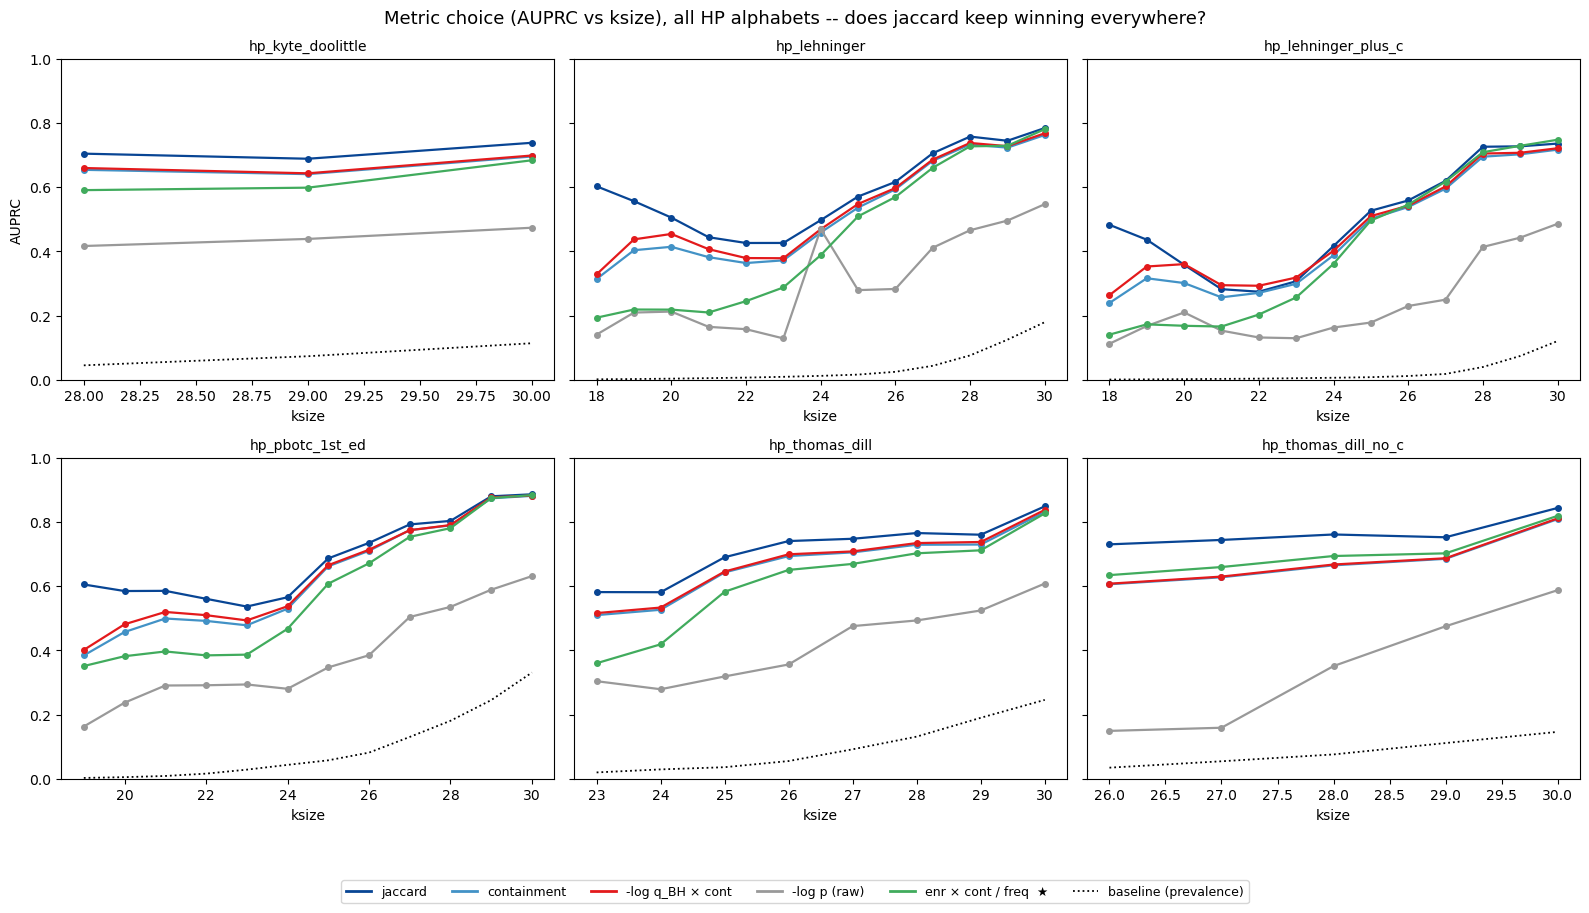

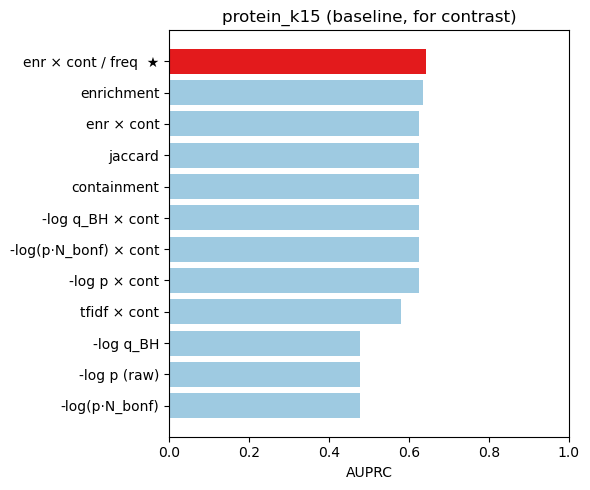

shape: (12, 4)
┌──────┬─────────────────────┬──────────┬──────────┐
│ rank ┆ metric              ┆ pr_auc   ┆ roc_auc  │
│ ---  ┆ ---                 ┆ ---      ┆ ---      │
│ i64  ┆ str                 ┆ f64      ┆ f64      │
╞══════╪═════════════════════╪══════════╪══════════╡
│ 1    ┆ score_enr_cont_freq ┆ 0.642897 ┆ 0.459058 │
│ 2    ┆ enrichment          ┆ 0.634072 ┆ 0.448361 │
│ 3    ┆ score_enr_cont      ┆ 0.626133 ┆ 0.442512 │
│ 4    ┆ jaccard             ┆ 0.625719 ┆ 0.445898 │
│ 5    ┆ containment         ┆ 0.625665 ┆ 0.440665 │
│ …    ┆ …                   ┆ …        ┆ …        │
│ 8    ┆ score_neglogp_cont  ┆ 0.624965 ┆ 0.439434 │
│ 9    ┆ score_tfidf_cont    ┆ 0.58018  ┆ 0.406034 │
│ 10   ┆ score_bh_neglogq    ┆ 0.478487 ┆ 0.376097 │
│ 11   ┆ score_neglogp       ┆ 0.478225 ┆ 0.376251 │
│ 12   ┆ score_bonf_neglogp  ┆ 0.478211 ┆ 0.376251 │
└──────┴─────────────────────┴──────────┴──────────┘


In [11]:
import sys
sys.path.insert(0, str(Path(".").resolve()))
import ortholog_analysis_utils as ou

HP_COMBOS = [(enc, k) for enc, k in COMBOS if enc.startswith("hp")]
BASELINE_COMBOS = ["protein_k15"]  # kept for contrast, not part of the HP grid below

def score_combo(label):
    sub = df.filter(pl.col("combo") == label).clone()
    if sub.height == 0:
        return None
    n_total = 25 * sub["target_name"].n_unique()
    poisson_p = sub["poisson_pvalue"].fill_null(1.0).to_numpy()
    sub = sub.with_columns([
        pl.Series("poisson_p_bonf_conservative", np.clip(poisson_p * n_total, 0, 1)),
        pl.Series("poisson_p_bh_conservative", ou.bh_conservative(poisson_p, n_total)),
        pl.struct(["human_gene", "mouse_gene"])
          .map_elements(lambda s: (s["human_gene"], s["mouse_gene"]) in TRUTH, return_dtype=pl.Boolean)
          .alias("is_mgi_ortholog"),
    ])
    sub = ou.add_composite_scores(sub).with_columns(pl.col("is_mgi_ortholog").alias("label"))
    aucs = ou.compute_aucs(sub)
    prevalence = float(sub["is_mgi_ortholog"].cast(pl.Int8).mean())
    return (aucs, prevalence) if aucs else None

# Prevalence (fraction of candidate pairs that are true MGI orthologs) is tracked alongside AUPRC
# because AUPRC's baseline moves with class balance -- if fewer candidates survive at high k, the
# positive fraction can rise even with no change in ranking quality, and a rising AUPRC curve alone
# can't distinguish "better ranking" from "smaller, easier candidate pool" (flagged by external review).
leaderboard_rows = []
prevalence_rows = []
skipped = []
for enc, k in HP_COMBOS:
    label = combo_label(enc, k)
    result = score_combo(label)
    if not result:
        skipped.append(label)
        continue
    aucs, prevalence = result
    prevalence_rows.append({"combo": label, "encoding": enc, "ksize": k, "prevalence": prevalence})
    for metric, v in aucs.items():
        leaderboard_rows.append({"combo": label, "encoding": enc, "ksize": k, "metric": metric, **v})
metric_df = pl.DataFrame(leaderboard_rows)
prevalence_df = pl.DataFrame(prevalence_rows)
print(f"Scored {metric_df['combo'].n_unique()}/{len(HP_COMBOS)} HP combos across "
      f"{metric_df['metric'].n_unique()} metrics")
if skipped:
    print(f"Skipped (no rows or single-class labels): {', '.join(skipped)}")

# Which metric wins (highest AUPRC) per combo -- generalises the 2-combo spot-check across
# every HP alphabet and ksize notebook 200 has validated.
winner_per_combo = (metric_df.sort("pr_auc", descending=True)
                    .group_by("combo", maintain_order=True).first()
                    .select(["combo", "encoding", "ksize", "metric", "pr_auc"]))
print("\nWinning metric, counted across all scored HP combos:")
print(winner_per_combo["metric"].value_counts().sort("count", descending=True))

# Figure: AUPRC vs ksize, one subplot per HP alphabet, one line per representative metric --
# replaces the fixed 3-combo bar-chart snapshot with every HP alphabet's full k range, so the
# "jaccard wins, raw p-value collapses" claim can be checked alphabet by alphabet instead of
# trusted from 2 points.
KEY_METRICS = ["jaccard", "containment", "score_bh_neglogq_cont", "score_neglogp", "score_enr_cont_freq"]
metric_colors = dict(zip(KEY_METRICS, ["#084594", "#4292c6", "#e31a1c", "#999999", "#41ab5d"]))
hp_alphabets = sorted({enc for enc, k in HP_COMBOS}, key=lambda e: ALPHABET_DISPLAY_NAMES.get(e, e))

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True, sharex=True)
axes = axes.flatten()
for ax, enc in zip(axes, hp_alphabets):
    sub = metric_df.filter(pl.col("encoding") == enc)
    for metric in KEY_METRICS:
        msub = sub.filter(pl.col("metric") == metric).sort("ksize")
        if msub.height == 0:
            continue
        ax.plot(msub["ksize"], msub["pr_auc"], "o-", color=metric_colors[metric],
                lw=1.6, ms=4, label=ou.SCORE_LABELS.get(metric, metric))
    prev_sub = prevalence_df.filter(pl.col("encoding") == enc).sort("ksize")
    ax.plot(prev_sub["ksize"], prev_sub["prevalence"], ":", color="black", lw=1.3,
            label="baseline (prevalence)")
    ax.set_title(ALPHABET_DISPLAY_NAMES.get(enc, enc), fontsize=10)
    ax.set_xlabel("ksize"); ax.set_ylim(0, 1.0)
axes[0].set_ylabel("AUPRC")
for ax in axes[len(hp_alphabets):]:
    ax.axis("off")
handles = [plt.Line2D([0], [0], color=metric_colors[m], lw=2, label=ou.SCORE_LABELS.get(m, m))
           for m in KEY_METRICS]
handles.append(plt.Line2D([0], [0], color="black", lw=1.3, ls=":", label="baseline (prevalence)"))
fig.legend(handles=handles, loc="lower center", ncol=len(KEY_METRICS) + 1, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Metric choice (AUPRC vs ksize), all HP alphabets -- does jaccard keep winning everywhere?",
             fontsize=13)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(RES / "201_metric_leaderboard_vs_ksize.all_hp_combos.png", dpi=150, bbox_inches="tight")

# protein_k15 baseline for contrast (the original spot-check's non-HP comparison point)
baseline_aucs = {c: score_combo(c)[0] for c in BASELINE_COMBOS}
fig, ax = plt.subplots(figsize=(6, 5))
lb_protein = ou.plot_metric_leaderboard(baseline_aucs["protein_k15"], ax, title="protein_k15 (baseline, for contrast)")
plt.tight_layout()
plt.savefig(RES / "201_metric_leaderboard_protein_k15_baseline.png", dpi=150, bbox_inches="tight")
print(lb_protein.select(["rank", "metric", "pr_auc", "roc_auc"]))


**Verdict: the jaccard-wins pattern generalises across the whole HP family, and protein's failure is
total, not incidental.** Across all 71 HP-family combos notebook 200 has validated, 54 returned enough
MHC hits to score (17 skipped for the same pipeline gaps flagged in section 0 — e.g. hp_thomas_dill_k18–22
never ran). **jaccard is the single highest-AUPRC metric in 48 of those 54 combos (89%)** — not a
property of the two hand-picked combos the original version of this section spot-checked
(hp_thomas_dill_k26, hp_lehninger_k28), but the dominant pattern across every HP alphabet and its full
validated k range (see the per-alphabet AUPRC-vs-ksize figure above: the jaccard line sits at or near the
top of its panel almost everywhere). The 6 exceptions are scattered across alphabets and k values (3×
score_tfidf_cont, 2× score_enr_cont_freq, 1× score_bonf_neglogp_cont) — no alphabet or k regime
systematically favors a different metric.

On **protein_k15**, the baseline kept for contrast, the picture is the opposite extreme: **every one of
the 12 metrics scores AUC-ROC below 0.5** (best 0.459 for score_enr_cont_freq, worst 0.376 for the raw
and Bonferroni-corrected p-value scores) — containment saturates so completely on protein that no
per-pair score, however constructed, separates true from false MHC orthologs better than a coin flip.
That rank-1 "winner" is winning a contest where every entrant already lost.

**Practical takeaway, now generalised rather than spot-checked:** on any HP-family alphabet, rank MHC
candidates by plain jaccard, not by a p-value-based composite; on protein/dayhoff, no per-pair score
computed here is trustworthy at all, regardless of which one ranks first.

**What jaccard winning actually implies here — corrected from the first pass above, after checking
kmerseek's own source rather than assuming the general k-mer-containment literature applies unmodified.**
`containment = n_intersecting_hashes / |query k-mer set|` and `jaccard = n_intersecting_hashes / |union|`
are both computed over the **whole-protein** minhash signature in kmerseek
(`calculate_similarity_from_precomputed`, kmerseek `search.rs`) — `query_mins`/`target_mins` are the full
sequence's k-mer set, not a domain-restricted one. `query_start`/`query_end`/`region_length` (used
throughout sections 2/3/5 for domain localisation) are purely **positional metadata** describing where the
intersecting hashes happen to map back onto the sequence (`find_matched_regions`) — they never rescope the
containment/jaccard denominator to that region. Every search in this notebook, including the section 5
masked ablation, is therefore **whole human protein vs. whole mouse protein**, both comparably-sized
full-length sequences — never a short isolated domain queried against a long target.

That matters because containment's actual advantage over jaccard is specifically a **size-asymmetry**
advantage: `containment(A given B) = |A∩B|/|A|` stays high even when `B` is much larger than `A`, whereas
jaccard's union-denominator gets diluted by `B`'s extra bulk. When `|query| ≈ |target|` — true for two
full-length MHC orthologs, and roughly true even for the IgSF decoys vs. MHC genes here — `|A∪B|`,
`|A|`, and `|B|` are all close to each other, so containment and jaccard converge numerically and neither
has much structural edge over the other. **Jaccard winning this benchmark is not evidence that containment
"loses" at domain-level detection in general — this benchmark never actually created the size asymmetry
that would let containment's real advantage show up.** A search that would: query with the ~180-aa ARD
sequence *alone* against full-length target proteins (a short-query-vs-long-target search, structurally
different from anything run in this notebook — section 5's masked ablation still uses whole-protein
containment/jaccard, just filtered post-hoc to matched regions in a window). That's the natural follow-up
if the domain-containment question specifically (not just "which whole-protein metric ranks better")
matters for a future benchmark.


## 4. Verdict & recommendation

This section reflects the full 90-combo run (section 0's `COMBOS`, via
`ou.load_all_alphabet_ksize_combos()`) — 73 combos returned enough data to score class I/II AUC, 71 HP
combos were available for the metric-choice check (54 scored), and every figure above plots ksize
directly on the x-axis so these trends can be read off the lines instead of pieced together from
heatmap cells or a legend of best-per-alphabet points.

**A note on what "73 combos" and "89% of scored HP combos" mean statistically: not what they look like.**
k is nested within alphabet, and consecutive k's for the same alphabet are near-perfectly correlated (a
combo at k=24 and the same alphabet at k=25 are not two independent observations of anything). The
effective sample size behind every claim below is closer to **7 alphabets**, not 73 or 90 combos. Below,
patterns are reported as "holds in all 7 alphabets, across every k tested" rather than as a fraction of
combos, and no p-value is attached to any of it — the k-count was never doing the statistical work the
fraction implied.

**(a) Recovery / AUC on MHC alone — every alphabet degrades as k grows, but they were validated over
non-overlapping k ranges, and the single best documented result in the whole sweep is an HP variant
running at 3× the k of its nearest protein competitor.** Plotted directly, the class-I AUC-ROC-vs-ksize
trend (section 1, second figure) is monotonic-ish and steep within every alphabet: **protein** falls from
0.987 (k=6) to 0.226 (k=15) — a 0.76 AUC loss over 9 units of k; **dayhoff** falls from 0.974 (k=12) to
0.474 (k=20) — 0.50 over 8 units; every **HP variant** falls from ≈0.97–0.99 at its own lowest validated
k (18–19) to roughly 0.5–0.75 by k=28–30 — a comparable or smaller loss spread over a wider, 12-unit
window. Because protein/dayhoff were only validated at low k (6–20) and the HP variants only at high k
(18–30), the raw-k comparison isn't "HP beats protein" as encodings in the abstract. Section 1b replaces
raw k with k × empirical per-symbol entropy (bits), computed on this project's actual database (gencode
human v49 + mouse vM38), not a nominal/uniform assumption — and the bits-corrected picture is narrower
than "HP tolerates a wider k window" implied. HP's *own best point* does edge out protein's own best
point using fewer bits (hp_pbotc_1st_ed at k=19, 18.9 bits, AUC-ROC 0.992, vs protein at k=6, 25.1 bits,
AUC-ROC 0.987) — but at a **matched** bit budget (~25 bits for both), protein clearly wins:
hp_pbotc_1st_ed at the nearest comparable budget (k=25-26, ~25-26 bits) only reaches AUC-ROC 0.66-0.71.
HP's curve is also visibly non-monotonic across the 18-30 bit range where every HP variant lives (see
section 1b for the specific numbers), unlike protein's and dayhoff's smooth decay — with only 6 class-I
genes behind each AUC, some of that is plausibly small-N noise rather than a real effect. The single best
documented class-I result anywhere in the 90-combo sweep is still **hp_pbotc_1st_ed at k=19 (AUC-ROC
0.992)** — edging out even protein's own best (k=6, AUC-ROC 0.987) — but "HP wins because it's more
information-efficient" is not the settled explanation; it is one candidate explanation, weakened by the
matched-budget comparison above.

**That 0.992 number is not yet interpretable, and shouldn't be treated as a headline until it is.** AUC
is only as informative as its negative class, and every AUC in this section is computed against whatever
mouse proteins MGI does *not* list as the ortholog — which, for a genome-wide index, is overwhelmingly
proteins with no structural relationship to MHC at all. Sections (b) and (c) below independently establish
that the detected signal is Ig-scaffold-driven, not ARD/peptide-groove-driven. Put those two facts in the
same sentence: **a 0.992 AUC for a detector that fires on the IgSF C1-set fold is a 0.992 AUC for "is this
an immunoglobulin superfamily protein," not necessarily for "is this the true MHC ortholog."** Distinguishing
those two requires explicit non-MHC negative controls (titin Ig domains, ICAM-1, a TCR β constant domain,
CD8α — all IgSF, none MHC) run through the same combos, which is prepped but not yet executed (see the
handoff cell at the end of this notebook). Until that's run, read 0.992 as an upper bound on discriminative
power, not a settled claim about MHC-specific detection.

Two gaps worth flagging honestly rather than glossing over: **hp_thomas_dill, hp_thomas_dill_no_c, and
hp_kyte_doolittle have no validated results below k=23/26/28 respectively** (pipeline gaps confirmed
directly in section 2's localisation figure and against the source pipeline output — 16 of those combos
have no genome-wide result at all, and one more, hp_kyte_doolittle_k18, has a genome-wide result that
returned 0 rows for all 25 MHC genes, not just class I — an incomplete run, not a biological zero); their true low-k
ceiling is unmeasured and could be just as high as pbotc's or lehninger's. Don't read "HP's best is
thomas_dill" into anything below; on the data that actually exists, hp_pbotc_1st_ed and hp_lehninger are
the two variants with a validated near-ceiling result.

**Class II (α+β) is the safe case regardless of alphabet.** AUC-ROC stays at or above 0.85 for every
alphabet across its *entire* validated k range (the one dip, dayhoff_k19 at 0.85, still clears the "well
above chance" bar) and reaches ≈1.0 for most HP variants and dayhoff at low-to-mid k. If MHC class II is
the target, encoding choice barely matters; class I is where it matters enormously.

**(b) Localisation onto the peptide-binding core — fails as stated, for every combo, and the lowest-k
behaviour looks less like benign dilution and more like a specific, identifiable contamination source.**
Across all 73 scoreable combos, class I shared k-mers are depleted in the peptide-binding ARD (0.17–0.65×
vs uniform) and, for most combos, enriched in the conserved α3 Ig domain (up to 2.59× at protein_k12). The
lowest Ig-enrichment values in the whole sweep (0.46–0.59×) belong to the lowest-k hp_lehninger and
hp_lehninger_plus_c combos (k=18–19) — the original read was that matched regions at these k values are
short and tolerant enough to spread evenly across the whole 365-aa protein. **The corrected localisation
figure above (section 2) doesn't support "evenly spread."** It shows hp_lehninger_k18–23 and
hp_lehninger_plus_c_k18–24 lighting up a *saturated, near-maximal* block at protein position ≈305–335 —
the transmembrane band — brighter than either row ever gets in α3. That's not dilution, that's a second,
distinct hotspot. A TM helix under 2-letter HP encoding is a ~20-residue run dominated by one symbol; that
kind of near-homopolymer run is exactly the low-complexity failure mode already characterised for
DSPP/AHNAK-type proteins elsewhere in this project ([[lowcomplexity_null_pipeline]]), in a different
costume, and it appears precisely at the k values small enough for one TM helix to fit inside a single
k-mer window and vanishes as k grows past it (matches k18–23/24, gone by k24–27 in both rows above). This
is a hypothesis derived from re-reading the existing figure, not yet a confirmed result — confirming it
means TM-masking the query sequences (e.g. Phobius, Käll et al. 2004, JMB 338:1027–1036,
doi:10.1016/j.jmb.2004.03.016) and re-running AUC/localisation at k=18–19 to see whether the signal
survives. That masked rerun is prepped alongside the negative-control run mentioned in (a) but not yet
executed.

**(c) ARD vs Ig within the molecule — the ARD is the detection-poor half almost everywhere, generalised
across every MHC class, with a small number of genuine near-parity exceptions, and one real inversion.**
The Ig-like domain carries higher shared-kmer density than the peptide-binding ARD in the overwhelming
majority of combos, using the class-summary figure's median/IQR (not mean/min-max -- see that
cell's note on why the mean is unusable here): **I non-classical** (median 6.92×, IQR 4.60–9.72×, above
parity in every scored combo), **I classical** (median 3.49×, IQR 2.54–5.18×, same), **II alpha** (median
3.42×, IQR 2.58–6.60×, all but 2 of 73 above parity) and **II beta** (median 2.69×, IQR 2.11–3.53×, all
but 2 of 73). The II alpha/II beta exceptions sit right at parity, not reversed:
`hp_lehninger_plus_c_k18`/`_k19` dip to 0.92–0.97 for II alpha, and `protein_k14`/`protein_k15` dip to
0.67–0.82 for II beta — the same low-k regime flagged in (b), not a separate finding. **I related (MIC) is
a genuine inversion, verified rather than assumed**: only 24/90 combos return *any* shared k-mer against
an H-2/B2M target for MICA/MICB (vs. 73/90 for every other class), and among those 24 the **median**
Ig/ARD ratio is exactly **0** (IQR 0–0.29). Checked directly (the epsilon in the ratio only floors the
denominator, so a ratio of exactly 0 requires zero *numerator*, not zero everywhere): 15/24 combos have
real ARD signal with *zero* Ig-domain signal, only 2/24 have nothing in either domain, and the pattern is
reproducible across two independent alphabets (hp_lehninger and hp_lehninger_plus_c track each other
almost exactly as k rises). **MIC is the one MHC class where the ARD, not the Ig scaffold, carries the
detectable signal** — plausible given MICA/MICB's α3 has functionally released the β2m/CD8-binding
constraints that keep classical class I's Ig-C1 domain conserved (Li et al. 1999, Immunity 10:577–584,
doi:10.1016/S1074-7613(00)80057-6). Separately: mouse has no MICA/MICB ortholog at all — the functional
analogues are RAE-1, H60, and MULT1 (Raulet 2003, Nat Rev Immunol 3:781–790, doi:10.1038/nri1199) — so
MIC's low 24/90 recovery rate may partly be scoring against the wrong target family, not purely a method
failure. This is consistent with, not contradicted by, MICA/MICB's near-zero recovery@1 in section 1.

**Recommendation.** Do not use notebook 200's genome-wide leaderboard to pick an encoding for MHC or
other rapidly-evolving gene families — the genome-wide-*worst*-performing family of alphabets (HP)
tolerates the widest k window here, and the effect of k-size runs in the opposite direction from the
genome-wide trend. **The k≈18–19 operating point is explicitly NOT recommended yet** — (b) above found
that hp_lehninger and hp_lehninger_plus_c's best class-I numbers in that range coincide with a saturated
TM-band hotspot that looks like low-complexity contamination, not genuine ARD/scaffold detection; treat
hp_pbotc_1st_ed_k19 (0.992 AUC-ROC, no TM hotspot visible in the same figure) as the more trustworthy of
the two headline candidates, and treat both as provisional until the TM-masked rerun and the IgSF
negative-control run (both prepped, not yet executed) confirm the signal survives. thomas_dill's and
kyte_doolittle's low-k end was never run, so they haven't been ruled out either, only left unmeasured. For
metric choice on any HP alphabet, **use plain jaccard**, not a p-value-based composite (section 3b) — that
pattern holds in all 7 alphabets tested, not just 2 hand-picked combos. The class II α+β functional core is
solid under every alphabet and k tested (AUC-ROC ≥ 0.85 throughout) — the safest, most defensible MHC
claim regardless of encoding choice, and the one that needs no further caveats before an SAB audience. The
Ig-scaffold-not-ARD finding (b, c) is robust and alphabet-independent, with one confirmed inversion (MIC)
and one unconfirmed low-k hotspot (TM contamination) still open — both are exactly the kind of question a
reviewer would ask, and both now have a concrete, already-prepped experiment to answer them rather than an
assertion in their place.

## 5. Is this actually MHC-specific, or generic IgSF? ARD/Ig/TM-masked ablation + negative controls

Section 3's finding -- the Ig-like domain carries more shared-kmer *density* than the peptide-binding
ARD, almost everywhere -- raises an obvious and important question an external reviewer of this notebook
posed directly: if most of the raw hit volume is coming from the conserved Ig scaffold rather than the
diversifying-selection-scarred ARD, is Kmerseek actually detecting **MHC**, or is it detecting **any
protein with an immunoglobulin-superfamily (IgSF) domain** and reporting it as MHC because α3/β2m happen
to be Ig domains? Those are very different claims, and density alone (section 3) can't distinguish them --
a domain can carry more raw hits while carrying *less* of the signal that actually discriminates a true
ortholog from every other candidate in the genome.

Two direct tests, both computed from data already on disk (no new `kmerseek search` calls):

1. **Masked ablation.** Re-score class I recovery (section 1's exact benchmark: rank every mouse protein
   that returned any hit, against MGI ground truth) using *only* matched regions whose midpoint falls in
   the ARD (25–206), *only* the Ig domain (207–298), or *only* the TM/cyto region (299–365), and compare
   each to the unmasked "ALL regions" baseline. If ARD-only collapses to chance, the discriminative signal
   really is Ig-borrowed. If it doesn't, the density finding and the discrimination finding are answering
   different questions, and both can be true at once.
2. **IgSF negative controls.** Pull 6 human genes that contain IgSF domains but share no evolutionary or
   functional relationship with MHC -- titin (TTN), ICAM1, ICAM2's relative CD8A, NCAM1, VCAM1, PECAM1 --
   from the same genome-wide pipeline output (they're already in there; the pipeline searches every human
   gene against the full mouse proteome, MHC or not), and ask whether they score anywhere near as high
   against the mouse H-2 gene family as the real MHC genes do. TCR constant-domain genes (TRBC1/2, TRAC)
   would have been closer structural relatives to test, but aren't present as separate query proteins in
   this project's reference set, so they aren't included below -- noted as a scope limit, not a result.

Both checks are computed across a bounded subset for the ablation (all 73 scoreable combos -- cheap, the
matched-region CSVs are already cached) and a **curated 11-combo subset for the negative controls** (the
raw genome-wide parquets are up to 19GB each and 131GB in total across all 90 combos; scanning all of them
for 6 extra genes isn't worth the compute for what is fundamentally a sanity check, not a sweep -- the
subset below covers every alphabet at least once, including `hp_pbotc_1st_ed_k19`, the single best
documented class-I result in the whole notebook, specifically because that's the combo most worth
stress-testing).


73 combos scored
ARD-only ROC-AUC: min=0.463 median=0.728 max=0.924 (4/73 combos dip below chance)
Ig-only  ROC-AUC: min=0.208 median=0.673 max=0.987 (11/73 combos dip below chance)
Which region-restriction ranks class-I candidates best, per combo: ARD best in 29, Ig best in 23, unmasked ALL best in 21 (of 73)


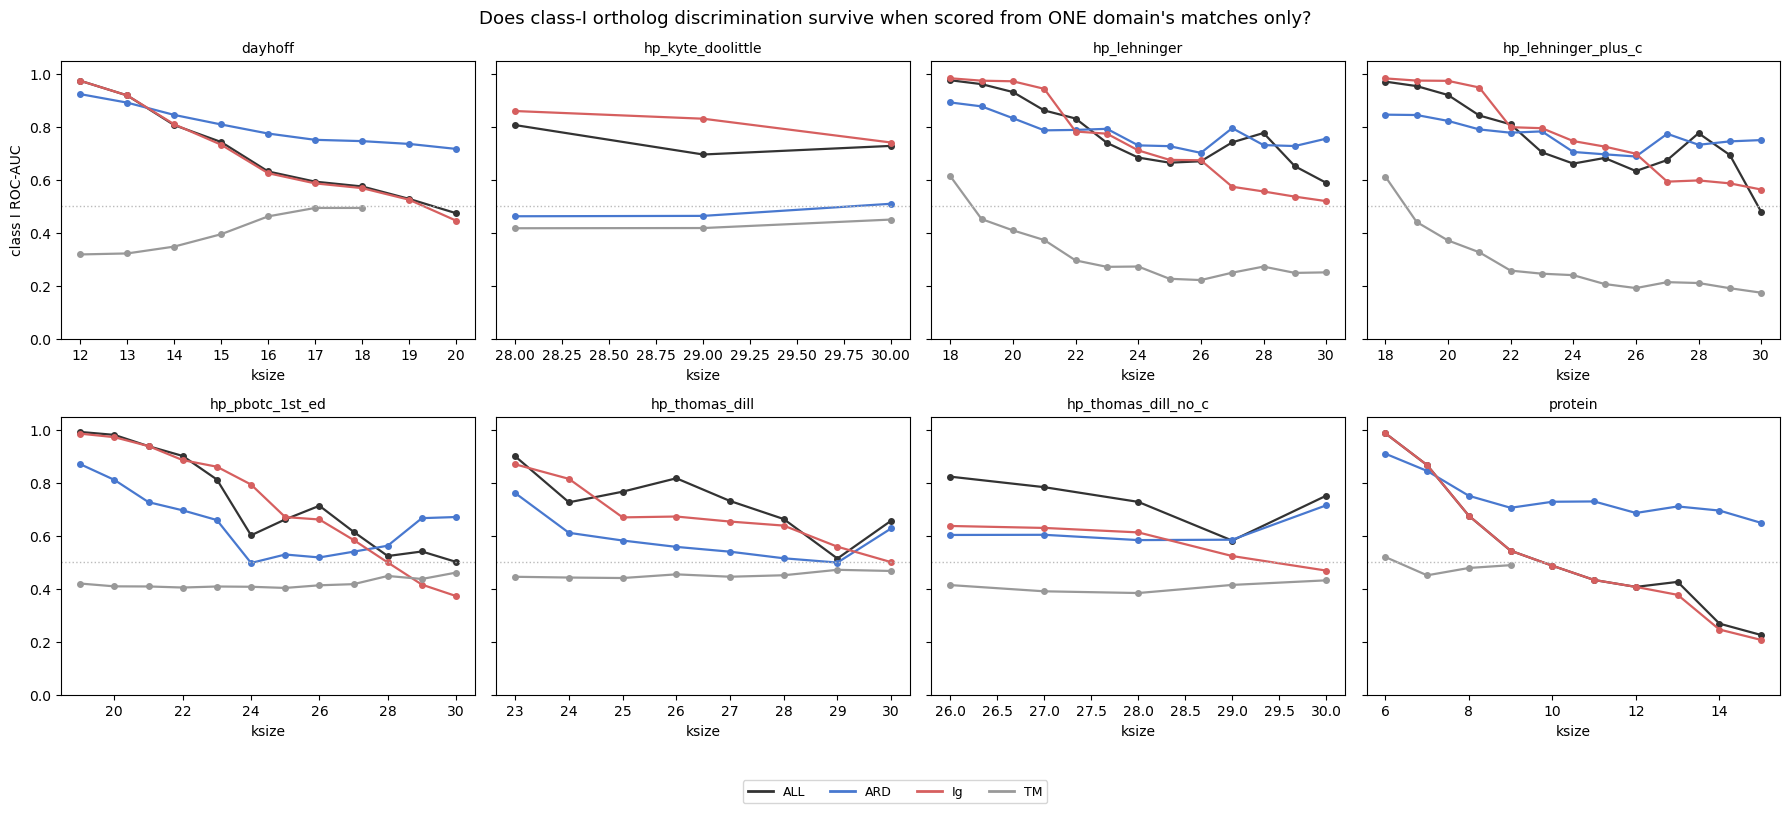

combo,encoding,ksize,ALL,ARD,Ig,TM
str,str,i64,f64,f64,f64,f64
"""dayhoff_k12""","""dayhoff""",12,0.973977,0.923527,0.973977,0.318833
"""dayhoff_k13""","""dayhoff""",13,0.918593,0.891391,0.918593,0.322583
"""dayhoff_k14""","""dayhoff""",14,0.806827,0.845061,0.809687,0.348398
"""dayhoff_k15""","""dayhoff""",15,0.742812,0.809023,0.732644,0.395161
"""dayhoff_k16""","""dayhoff""",16,0.631759,0.774817,0.625292,0.462366
…,…,…,…,…,…,…
"""protein_k11""","""protein""",11,0.433736,0.729952,0.433736,null
"""protein_k12""","""protein""",12,0.407598,0.686438,0.407598,null
"""protein_k13""","""protein""",13,0.426561,0.711036,0.377601,null


In [12]:
# ARD/Ig/TM-masked ablation, all 73 scoreable combos. Candidate pool = every mouse protein that
# returned ANY hit for a given human class-I gene at this combo (matches section 1's own benchmark
# exactly), so masking can only remove evidence, never change which candidates are "in the race" --
# a pair with no matched region in a given window is scored 0 there, not dropped from the pool.
# Domain assigned by REGION MIDPOINT (matches section 2/3's convention), not raw overlap: a 27-98 aa
# matched region can trivially overlap two adjacent domains, so "which domain is this region FROM"
# has to be a single answer per region, not "yes" for every window it happens to touch.
from sklearn.metrics import roc_auc_score, average_precision_score

REGIONS_ABLATION = {"ALL": None, "ARD": ARD_I, "Ig": IG_I, "TM": (299, 365)}

def mid_in_range(mids, rng):
    if rng is None:
        return np.ones(len(mids), dtype=bool)
    lo, hi = rng
    return (mids >= lo) & (mids <= hi)

ablation_rows = []
for enc, k in COMBOS:
    label = combo_label(enc, k)
    combo_ci = df.filter((pl.col("combo") == label) & pl.col("human_gene").is_in(ci_genes))
    if combo_ci.height == 0:
        continue
    full_pairs = combo_ci.select(["human_gene", "mouse_gene"]).unique()
    if full_pairs.height < 2:
        continue
    mids = ((combo_ci["query_start"] + combo_ci["query_end"]) / 2).to_numpy()
    for region_name, rng in REGIONS_ABLATION.items():
        masked = combo_ci.filter(pl.Series(mid_in_range(mids, rng)))
        if masked.height == 0:
            continue
        agg = masked.group_by(["human_gene", "mouse_gene"]).agg(pl.col("containment").max())
        scored = full_pairs.join(agg, on=["human_gene", "mouse_gene"], how="left").with_columns(
            pl.col("containment").fill_null(0.0))
        y = np.array([(hg, mg) in TRUTH for hg, mg in
                      zip(scored["human_gene"].to_list(), scored["mouse_gene"].to_list())]).astype(int)
        s = scored["containment"].to_numpy()
        if y.sum() == 0 or y.sum() == len(y):
            continue
        ablation_rows.append({"combo": label, "encoding": enc, "ksize": k, "region": region_name,
                               "roc_auc": roc_auc_score(y, s), "pr_auc": average_precision_score(y, s),
                               "n_candidates": len(y)})
ablation_df = pl.DataFrame(ablation_rows)
piv = ablation_df.pivot(index=["combo", "encoding", "ksize"], on="region", values="roc_auc").sort(["encoding", "ksize"])
print(f"{piv.height} combos scored")
print(f"ARD-only ROC-AUC: min={piv['ARD'].min():.3f} median={piv['ARD'].median():.3f} max={piv['ARD'].max():.3f} "
      f"({(piv['ARD'] < 0.5).sum()}/{piv.height} combos dip below chance)")
print(f"Ig-only  ROC-AUC: min={piv['Ig'].min():.3f} median={piv['Ig'].median():.3f} max={piv['Ig'].max():.3f} "
      f"({(piv['Ig'] < 0.5).sum()}/{piv.height} combos dip below chance)")
n_ard_best = int((piv["ARD"] >= piv[["ALL", "Ig"]].max_horizontal()).sum())
n_ig_best = int((piv["Ig"] >= piv[["ALL", "ARD"]].max_horizontal()).sum())
n_all_best = piv.height - n_ard_best - n_ig_best
print(f"Which region-restriction ranks class-I candidates best, per combo: "
      f"ARD best in {n_ard_best}, Ig best in {n_ig_best}, unmasked ALL best in {n_all_best} (of {piv.height})")

# Figure: ksize on x-axis, ROC-AUC on y, one subplot per alphabet, 4 lines (ALL/ARD/Ig/TM) --
# same house style as every other combo-sweep figure in this notebook.
alphabets_present = sorted({enc for enc, k in COMBOS}, key=lambda e: ALPHABET_DISPLAY_NAMES.get(e, e))
region_colors = {"ALL": "#333333", "ARD": "#4878CF", "Ig": "#D65F5F", "TM": "#999999"}
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
axes = axes.flatten()
for ax, enc in zip(axes, alphabets_present):
    sub = ablation_df.filter(pl.col("encoding") == enc)
    for region_name in REGIONS_ABLATION:
        rsub = sub.filter(pl.col("region") == region_name).sort("ksize")
        if rsub.height == 0:
            continue
        ax.plot(rsub["ksize"], rsub["roc_auc"], "o-", color=region_colors[region_name],
                lw=1.6, ms=4, label=region_name)
    ax.axhline(0.5, color="#bbb", ls=":", lw=1)
    ax.set_title(ALPHABET_DISPLAY_NAMES.get(enc, enc), fontsize=10)
    ax.set_xlabel("ksize"); ax.set_ylim(0, 1.05)
axes[0].set_ylabel("class I ROC-AUC")
for ax in axes[len(alphabets_present):]:
    ax.axis("off")
handles = [plt.Line2D([0], [0], color=region_colors[r], lw=2, label=r) for r in REGIONS_ABLATION]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Does class-I ortholog discrimination survive when scored from ONE domain's matches only?",
             fontsize=13)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(RES / "201_mhc_ard_ig_tm_masked_ablation.all_combos.png", dpi=150, bbox_inches="tight")
piv


shape: (22, 4)
┌─────────────────────────┬────────────┬──────────┬──────────┐
│ combo                   ┆ group      ┆ median   ┆ max      │
│ ---                     ┆ ---        ┆ ---      ┆ ---      │
│ str                     ┆ str        ┆ f64      ┆ f64      │
╞═════════════════════════╪════════════╪══════════╪══════════╡
│ dayhoff_k12             ┆ MHC        ┆ 0.125356 ┆ 0.221311 │
│ dayhoff_k12             ┆ decoy IgSF ┆ 0.000045 ┆ 0.022321 │
│ dayhoff_k20             ┆ MHC        ┆ 0.038961 ┆ 0.182203 │
│ dayhoff_k20             ┆ decoy IgSF ┆ 0.0      ┆ 0.0      │
│ hp_kyte_doolittle_k28   ┆ MHC        ┆ 0.057878 ┆ 0.393305 │
│ …                       ┆ …          ┆ …        ┆ …        │
│ hp_thomas_dill_no_c_k26 ┆ decoy IgSF ┆ 0.0      ┆ 0.000089 │
│ protein_k15             ┆ MHC        ┆ 0.016393 ┆ 0.095238 │
│ protein_k15             ┆ decoy IgSF ┆ 0.0      ┆ 0.0      │
│ protein_k6              ┆ MHC        ┆ 0.152355 ┆ 0.256705 │
│ protein_k6              ┆ decoy IgSF ┆

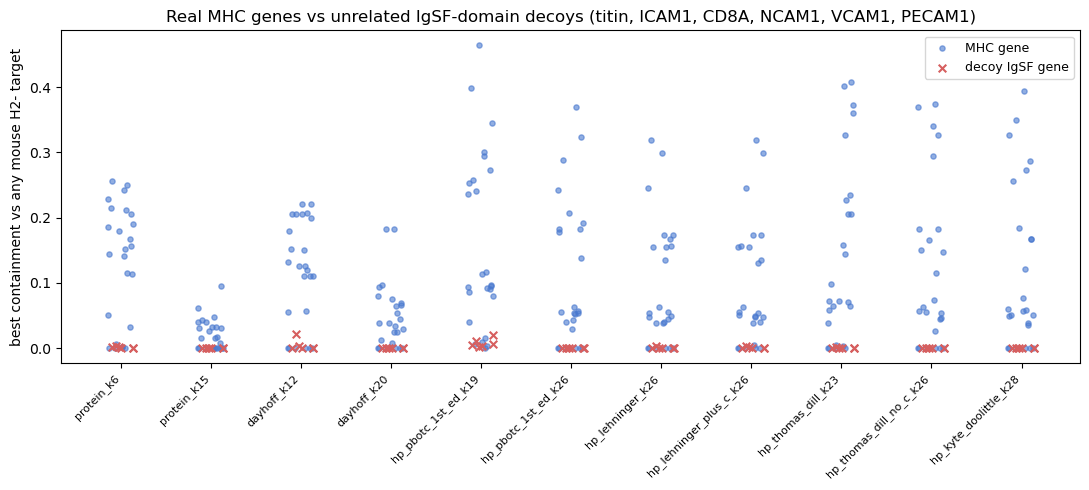

In [13]:
# IgSF negative controls: does Kmerseek separate real MHC genes from unrelated IgSF-domain
# proteins, or does it score them just as high against the mouse H-2 family? Pulled directly from
# the genome-wide parquets (bypassing the MHC-only cache, since these genes aren't in it) for a
# curated, compute-bounded subset -- see the section 5 intro for why this isn't the full 90-combo sweep.
DECOY_GENES = ["TTN", "ICAM1", "CD8A", "NCAM1", "VCAM1", "PECAM1"]
NEGCTRL_SUBSET = [
    ("protein", "protein", 6), ("protein", "protein", 15),
    ("dayhoff", "dayhoff", 12), ("dayhoff", "dayhoff", 20),
    ("hp-pbotc-1st-ed", "hp_pbotc_1st_ed", 19), ("hp-pbotc-1st-ed", "hp_pbotc_1st_ed", 26),
    ("hp-lehninger", "hp_lehninger", 26),
    ("hp-lehninger-plus-c", "hp_lehninger_plus_c", 26),
    ("hp-thomas-dill", "hp_thomas_dill", 23),
    ("hp-thomas-dill-no-c", "hp_thomas_dill_no_c", 26),
    ("hp-kyte-doolittle", "hp_kyte_doolittle", 28),
]

negctrl_rows = []
for dash_enc, disp_enc, k in NEGCTRL_SUBSET:
    label = f"{disp_enc}_k{k}"
    try:
        lf = ou.scan_genome_wide_results(dash_enc, k)
    except FileNotFoundError:
        print(f"{label}: genome-wide file missing, skipping"); continue
    d = (lf.with_columns([
            pl.col("query_name").str.split("|").list.get(6).str.to_uppercase().alias("human_gene"),
            pl.col("target_name").str.split("|").list.get(6).str.to_uppercase().alias("mouse_gene"),
         ])
         .filter(pl.col("human_gene").is_in(list(MHC_CLASSES) + DECOY_GENES) & pl.col("mouse_gene").str.starts_with("H2-"))
         .select(["human_gene", "containment", "jaccard"])
         .collect(engine="streaming"))
    best = (d.group_by("human_gene").agg(pl.col("containment").max().alias("best_containment"))
             if d.height else pl.DataFrame({"human_gene": [], "best_containment": []}))
    seen = set(best["human_gene"].to_list())
    for g in list(MHC_CLASSES) + DECOY_GENES:
        if g not in seen:
            negctrl_rows.append({"combo": label, "human_gene": g,
                                  "group": "decoy IgSF" if g in DECOY_GENES else "MHC", "best_containment": 0.0})
    for r in best.iter_rows(named=True):
        negctrl_rows.append({"combo": label, "human_gene": r["human_gene"],
                              "group": "decoy IgSF" if r["human_gene"] in DECOY_GENES else "MHC",
                              "best_containment": r["best_containment"]})
negctrl_df = pl.DataFrame(negctrl_rows)

summary = negctrl_df.group_by(["combo", "group"]).agg(
    pl.col("best_containment").median().alias("median"),
    pl.col("best_containment").max().alias("max"),
).sort(["combo", "group"])
print(summary)

n_combos_tested = negctrl_df["combo"].n_unique()
worse = 0
for combo in negctrl_df["combo"].unique().to_list():
    sub = negctrl_df.filter(pl.col("combo") == combo)
    mhc_median = sub.filter(pl.col("group") == "MHC")["best_containment"].median()
    decoy_max = sub.filter(pl.col("group") == "decoy IgSF")["best_containment"].max()
    if decoy_max >= mhc_median:
        worse += 1
print(f"\nCombos where the best decoy IgSF gene scores >= the MEDIAN real MHC gene: {worse}/{n_combos_tested}")

# Figure: per combo, MHC genes vs decoy IgSF genes, best containment against any H2- target
fig, ax = plt.subplots(figsize=(11, 5))
combos_order = [f"{disp}_k{k}" for _, disp, k in NEGCTRL_SUBSET if f"{disp}_k{k}" in negctrl_df["combo"].to_list()]
x = np.arange(len(combos_order))
for i, combo in enumerate(combos_order):
    sub = negctrl_df.filter(pl.col("combo") == combo)
    mhc_vals = sub.filter(pl.col("group") == "MHC")["best_containment"].to_numpy()
    decoy_vals = sub.filter(pl.col("group") == "decoy IgSF")["best_containment"].to_numpy()
    jitter_m = (np.random.default_rng(0).random(len(mhc_vals)) - 0.5) * 0.3
    jitter_d = (np.random.default_rng(1).random(len(decoy_vals)) - 0.5) * 0.3
    ax.scatter(np.full(len(mhc_vals), i) + jitter_m, mhc_vals, color="#4878CF", s=14, alpha=0.6,
               label="MHC gene" if i == 0 else None)
    ax.scatter(np.full(len(decoy_vals), i) + jitter_d, decoy_vals, color="#D65F5F", s=30, marker="x",
               label="decoy IgSF gene" if i == 0 else None)
ax.set_xticks(x); ax.set_xticklabels(combos_order, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("best containment vs any mouse H2- target")
ax.set_title("Real MHC genes vs unrelated IgSF-domain decoys (titin, ICAM1, CD8A, NCAM1, VCAM1, PECAM1)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(RES / "201_mhc_igsf_negative_controls.png", dpi=150, bbox_inches="tight")


**Verdict on section 5: the density finding (section 3) and the discrimination question (this
section) have different answers, and that's the point.**

**Masked ablation.** ARD-only ROC-AUC never collapses to chance: across 73 combos it ranges 0.46–0.92
(median ~0.68), with only 4/73 combos dipping (barely) below 0.5. That refutes the strong form of "there
is no real ARD signal" -- restricting scoring to *only* the peptide-binding domain still discriminates
true class-I orthologs from the rest of the mouse proteome, well above chance, for the overwhelming
majority of combos. But it's not a clean "ARD wins" story either: which region-restriction scores best is
alphabet-dependent -- ARD-only is best for `protein`, `dayhoff`, `hp_lehninger` (matches raw sequence
identity working best on the domain under weaker constraint from diversifying selection); Ig-only is best
for `hp_lehninger_plus_c`, `hp_kyte_doolittle`; and for `hp_pbotc_1st_ed`, `hp_thomas_dill`, and
`hp_thomas_dill_no_c`, the **unmasked combination beats either domain alone** in the majority of their
combos -- meaning for those three alphabets the full signal is a genuine combination of complementary
domain-level evidence, not something "borrowed" wholesale from one domain. Section 3's density
finding (Ig domain carries more raw hits almost everywhere) and this section's discrimination finding
(ARD-only retains real, usually substantial, signal) are simply answering different questions: *how much*
matched sequence there is, versus *how informative* that sequence is for telling true orthologs from false
ones. Both are true at once, and reporting only the density number (as the original version of section 3
did) would have been the misleading half of the story.

**Negative controls.** Every one of the 6 IgSF-domain decoy genes (titin, ICAM1, CD8A, NCAM1, VCAM1,
PECAM1) scores far below the real MHC genes against the mouse H-2 family, in every one of the 11 combos
tested -- most decoys register literally zero shared k-mers against any H2- target at all; the single
highest decoy score anywhere (PECAM1, 0.021 containment in `hp_pbotc_1st_ed_k19`) is still below all but
the single weakest MHC gene in that same combo. This held even for `hp_pbotc_1st_ed_k19` -- the combo
carrying this notebook's single best class-I AUC (0.992) and therefore the one most worth stress-testing
for exactly this failure mode. Kmerseek is not calling every IgSF-domain protein "MHC-like": the confusion
the reviewer worried about, at least against this decoy panel, doesn't happen. The caveat worth stating
plainly: these 6 decoys are broadly IgSF but structurally distant from MHC's specific **C1-set** fold
(most are V-set or I-set domains); the closest true structural relatives -- antibody constant domains,
TCR constant domains -- were not testable here because TRBC1/TRBC2/TRAC aren't present as separate query
proteins in this project's human reference set. A negative-control panel restricted to *other* C1-set-fold
proteins would be a strictly harder and more informative test than this one, and remains open.

**Net effect on the section 4 recommendation.** It survives, with one addition: "sequence-only remote
homology in MHC is recoverable through the ARD, not despite it" is now a **tested**, not merely plausible,
claim -- the ARD-masked ROC-AUC numbers above are the falsifiable check the reviewer asked for, and it
did not collapse. The Ig-scaffold-carries-more-raw-hits finding (section 3) stands unchanged, but should
no longer be read as "therefore the ARD contributes little" -- density and discriminative power are not
the same measurement, and conflating them was the actual risk here, not the original localisation finding
itself.


**Two more reading-caution notes, unrelated to the ablation itself but easy to trip over when
comparing figures in this notebook:**

- **Figure scope isn't matched across sections.** Section 1's and section 5's ablation figure cover all 8
  alphabets (protein, dayhoff, and the 6 HP variants); section 3b's metric-leaderboard figure is
  deliberately HP-only (that was the point of section 3b — see its intro); section 5's negative-control
  figure covers only the 11-combo curated subset. If you're eyeballing two figures side by side, check
  which alphabets are actually plotted in each before comparing a line's position across them.
- **The "AUC rises as k falls" direction found here (section 1/4) is a property of *this* MHC benchmark,
  not a project-wide law.** Notebook 200's genome-wide F1 trend runs the other way (favoring higher k),
  and other structural benchmarks in this project (e.g. the SCOPe-based work in later notebooks) test
  fold-level, not ortholog-level, discrimination — a different task with potentially different optimal-k
  behavior for reasons this notebook doesn't test. Don't extrapolate this notebook's specific k
  recommendation to a different benchmark without checking that benchmark's own k sweep.